# Four-Bar Mechanism Synthesis & Design Space Exploration

**Author:** Based on work by Luis A. Rodríguez Arenas — extended for coupler-curve synthesis  
**References:** Norton — *Design of Machinery*, 5th ed.; Kota — *Design Space of Four-Bar Mechanisms*

---

## Introduction

The **four-bar linkage** is the simplest closed-loop mechanism and the workhorse of mechanical design. It consists of four rigid links connected by four revolute (pin) joints:

| Link | Symbol | Role |
|------|--------|------|
| Ground | $L_1$ | Fixed frame |
| Crank  | $L_2$ | Driver (full rotation or oscillation) |
| Coupler | $L_3$ | Connects crank to rocker |
| Rocker  | $L_4$ | Output link |

A point **P** rigidly attached to the coupler traces a **coupler curve** whose shape depends on the five design parameters $(L_1, L_2, L_3, L_4, BP, \gamma)$. The space of achievable coupler curves is enormous, and systematically exploring it — finding which mechanism produces a desired path — is the core problem of **kinematic synthesis**.

### Scope of this notebook

1. Rigorous position kinematics (vector-loop, Freudenstein equation)
2. Full coupler-curve generation with singularity handling
3. Parametric sweeps → libraries of coupler curves
4. Geometric shape metrics → quantitative classification
5. 2D maps à la Norton Fig. 3-21/3-22
6. 3D interactive design-space map (Plotly)
7. Trajectory synthesis via global + local optimisation
8. Results, validation and engineering conclusions

---
## 0. Imports & configuration

In [4]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings, itertools, time
warnings.filterwarnings('ignore')

# ── Numerics ──────────────────────────────────────────────────────────────────
import numpy as np
from numpy import deg2rad, rad2deg, pi
from scipy.optimize import fsolve, minimize, differential_evolution, basinhopping
from scipy.spatial.distance import directed_hausdorff
from scipy.spatial import ConvexHull
import scipy.spatial as spatial

# ── Machine learning ──────────────────────────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

try:
    import plotly.graph_objects as go
    import plotly.express as px
    from plotly.subplots import make_subplots
    PLOTLY_OK = True
except ImportError:
    PLOTLY_OK = False
    print("Plotly not available — interactive plots will use Matplotlib fallback")

# ── Global style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'lines.linewidth': 1.8,
    'font.size': 10,
})
np.set_printoptions(precision=5, suppress=True)
print("Dependencies loaded ✓")

Dependencies loaded ✓


---
## 1. Geometric definition & kinematic model

### 1.1 Vector-loop equation

Place the fixed pivot $O_2$ at the origin, with $O_4$ at $(L_1, 0)$.
The four-bar vector loop reads:

$$\mathbf{r}_2 + \mathbf{r}_3 = \mathbf{r}_1 + \mathbf{r}_4$$

Projecting onto $x$ and $y$:

$$L_2\cos\theta_2 + L_3\cos\theta_3 = L_1 + L_4\cos\theta_4 \tag{1a}$$
$$L_2\sin\theta_2 + L_3\sin\theta_3 = L_4\sin\theta_4 \tag{1b}$$

Eliminating $\theta_3$ yields the **Freudenstein equation** (used for verification):

$$K_1\cos\theta_4 - K_2\cos\theta_2 + K_3 = \cos(\theta_2 - \theta_4) \tag{2}$$

where $K_1 = L_1/L_4$, $K_2 = L_1/L_2$, $K_3 = (L_2^2 - L_3^2 + L_4^2 + L_1^2)/(2L_2 L_4)$.

### 1.2 Grashof condition

Let $s = \min(L_i)$, $l = \max(L_i)$, $p, q$ the remaining two.  
**Grashof**: $s + l \leq p + q$ → at least one link can make a full revolution.

### 1.3 Coupler point P

P is fixed in the coupler body at offset $(d, \gamma)$ from $A$:

$$\mathbf{r}_P = \mathbf{r}_A + d\begin{pmatrix}\cos(\theta_3+\gamma)\\ \sin(\theta_3+\gamma)\end{pmatrix}$$

Grashof: True  |  Type: crank-rocker


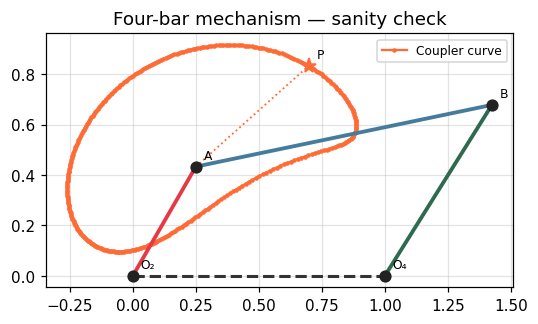

Curve has 360 valid points


In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# MODULE: Four-Bar Mechanism
# ═══════════════════════════════════════════════════════════════════════════════

class FourBar:
    """
    Planar four-bar linkage — complete kinematic model.

    Nomenclature (Norton, Design of Machinery, Ch. 4):
        L1 = ground link (fixed)
        L2 = crank  (driver, rotates from O2)
        L3 = coupler
        L4 = rocker (output, pivots at O4)
        d  = distance O2→P measured on the coupler body
        gamma = angle of AP w.r.t. the coupler axis AB [rad]

    Coordinate system:
        O2 at origin, O4 at (L1, 0)
        theta2 = crank angle (measured from +x axis, CCW positive)
    """

    def __init__(self, L1: float, L2: float, L3: float, L4: float,
                 d: float = 0.0, gamma: float = 0.0):
        self.L1 = float(L1)
        self.L2 = float(L2)
        self.L3 = float(L3)
        self.L4 = float(L4)
        self.d  = float(d)
        self.gamma = float(gamma)
        self._z0 = np.array([0.3, 2.5])   # continuation seed [theta3, theta4]

    # ── Grashof ───────────────────────────────────────────────────────────────
    def grashof(self) -> dict:
        """
        Returns Grashof classification.
        Reference: Norton §2.4
        """
        links = np.array([self.L1, self.L2, self.L3, self.L4])
        s, l = links.min(), links.max()
        others = np.sort(links)[[1, 2]]
        condition = (s + l) <= (others[0] + others[1])
        shortest = np.argmin(links)   # 0=L1,1=L2,2=L3,3=L4
        if condition:
            types = {0: 'double-crank', 1: 'crank-rocker',
                     2: 'double-rocker', 3: 'rocker-crank'}
            mech_type = types.get(shortest, 'crank-rocker')
        else:
            mech_type = 'triple-rocker (non-Grashof)'
        return {'grashof': condition, 'type': mech_type,
                's': s, 'l': l, 'condition_value': s + l}

    # ── Loop-closure (scalar residuals) ──────────────────────────────────────
    def _loop_residuals(self, angles23: np.ndarray, theta2: float) -> np.ndarray:
        """
        Residuals of the two scalar loop equations (1a, 1b).
        angles23 = [theta3, theta4]
        """
        th3, th4 = angles23
        f1 = (self.L2 * np.cos(theta2) + self.L3 * np.cos(th3)
              - self.L1 - self.L4 * np.cos(th4))
        f2 = (self.L2 * np.sin(theta2) + self.L3 * np.sin(th3)
              - self.L4 * np.sin(th4))
        return np.array([f1, f2])

    # ── Forward kinematics ───────────────────────────────────────────────────
    def FK(self, theta2: float, branch: int = 1) -> tuple:
        """
        Solve position problem for a given crank angle.

        Parameters
        ----------
        theta2 : float  — crank angle [rad]
        branch : int    — assembly branch (+1 open, -1 crossed)

        Returns
        -------
        (theta3, theta4) : tuple[float, float]
        success          : bool
        """
        sol, info, ier, _ = fsolve(
            self._loop_residuals, self._z0,
            args=(theta2,), full_output=True
        )
        success = (ier == 1) and (np.max(np.abs(info['fvec'])) < 1e-8)
        if success:
            self._z0 = sol.copy()   # warm-start continuation
        return sol, success

    # ── Joint positions ───────────────────────────────────────────────────────
    def joint_positions(self, theta2: float) -> dict:
        """
        Returns positions of all joints and coupler point P.
        """
        (th3, th4), ok = self.FK(theta2)
        O2 = np.array([0.0, 0.0])
        O4 = np.array([self.L1, 0.0])
        A  = O2 + self.L2 * np.array([np.cos(theta2), np.sin(theta2)])
        B  = O4 + self.L4 * np.array([np.cos(th4), np.sin(th4)])
        # Coupler point P: offset d at angle (theta3 + gamma) from A
        P  = A  + self.d  * np.array([np.cos(th3 + self.gamma),
                                       np.sin(th3 + self.gamma)])
        return {'O2': O2, 'A': A, 'B': B, 'O4': O4, 'P': P,
                'theta3': th3, 'theta4': th4, 'ok': ok}

    # ── Coupler curve ─────────────────────────────────────────────────────────
    def coupler_curve(self, n_points: int = 360) -> np.ndarray:
        """
        Trace the full coupler curve for one crank revolution.

        Returns
        -------
        np.ndarray of shape (n_valid, 2) — (x, y) of point P.
        """
        self._z0 = np.array([0.3, 2.5])   # reset to avoid hysteresis
        curve = []
        for theta2 in np.linspace(0, 2 * pi, n_points + 1)[:-1]:
            pts = self.joint_positions(theta2)
            if pts['ok']:
                curve.append(pts['P'])
        return np.array(curve) if curve else np.empty((0, 2))

    # ── Plot single pose ──────────────────────────────────────────────────────
    def plot_pose(self, theta2: float, ax=None, show_labels: bool = True,
                  color_map: dict = None) -> None:
        """
        Draw the mechanism at a given crank angle.
        """
        pts = self.joint_positions(theta2)
        if not pts['ok']:
            return
        if ax is None:
            ax = plt.gca()
        cmap = color_map or {'crank': '#E63946', 'coupler': '#457B9D',
                              'rocker': '#2D6A4F', 'ground': '#333333'}
        O2, A, B, O4, P = (pts[k] for k in ['O2', 'A', 'B', 'O4', 'P'])

        def seg(p1, p2, c, lw=2.5, ls='-'):
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], c=c, lw=lw, ls=ls)

        seg(O2, A,  cmap['crank'])
        seg(A,  B,  cmap['coupler'])
        seg(O4, B,  cmap['rocker'])
        seg(O2, O4, cmap['ground'], lw=2, ls='--')

        for p, mk in [(O2,'s'), (A,'o'), (B,'o'), (O4,'s')]:
            ax.plot(*p, 'o', ms=7, color='#222222', zorder=5)
        if self.d > 0:
            ax.plot(*P, '*', ms=10, color='#FF6B35', zorder=6)
            seg(A, P, '#FF6B35', lw=1.2, ls=':')

        if show_labels:
            for label, pos in [('O₂', O2), ('A', A), ('B', B),
                                ('O₄', O4), ('P', P)]:
                ax.annotate(label, pos, textcoords='offset points',
                            xytext=(5, 5), fontsize=8)
        ax.set_aspect('equal')

# ─── Quick sanity-check ───────────────────────────────────────────────────────
mech_test = FourBar(L1=1.0, L2=0.5, L3=1.2, L4=0.8, d=0.6, gamma=deg2rad(30))
g_info = mech_test.grashof()
print(f"Grashof: {g_info['grashof']}  |  Type: {g_info['type']}")

fig, ax = plt.subplots(figsize=(5, 5))
curve = mech_test.coupler_curve(360)
ax.plot(curve[:, 0], curve[:, 1], 'o-', ms=2, lw=1.5, color='#FF6B35',
        label='Coupler curve')
mech_test.plot_pose(deg2rad(60), ax=ax)
ax.set_title('Four-bar mechanism — sanity check')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f"Curve has {len(curve)} valid points")

---
## 2. Coupler curves — visualisation and animation

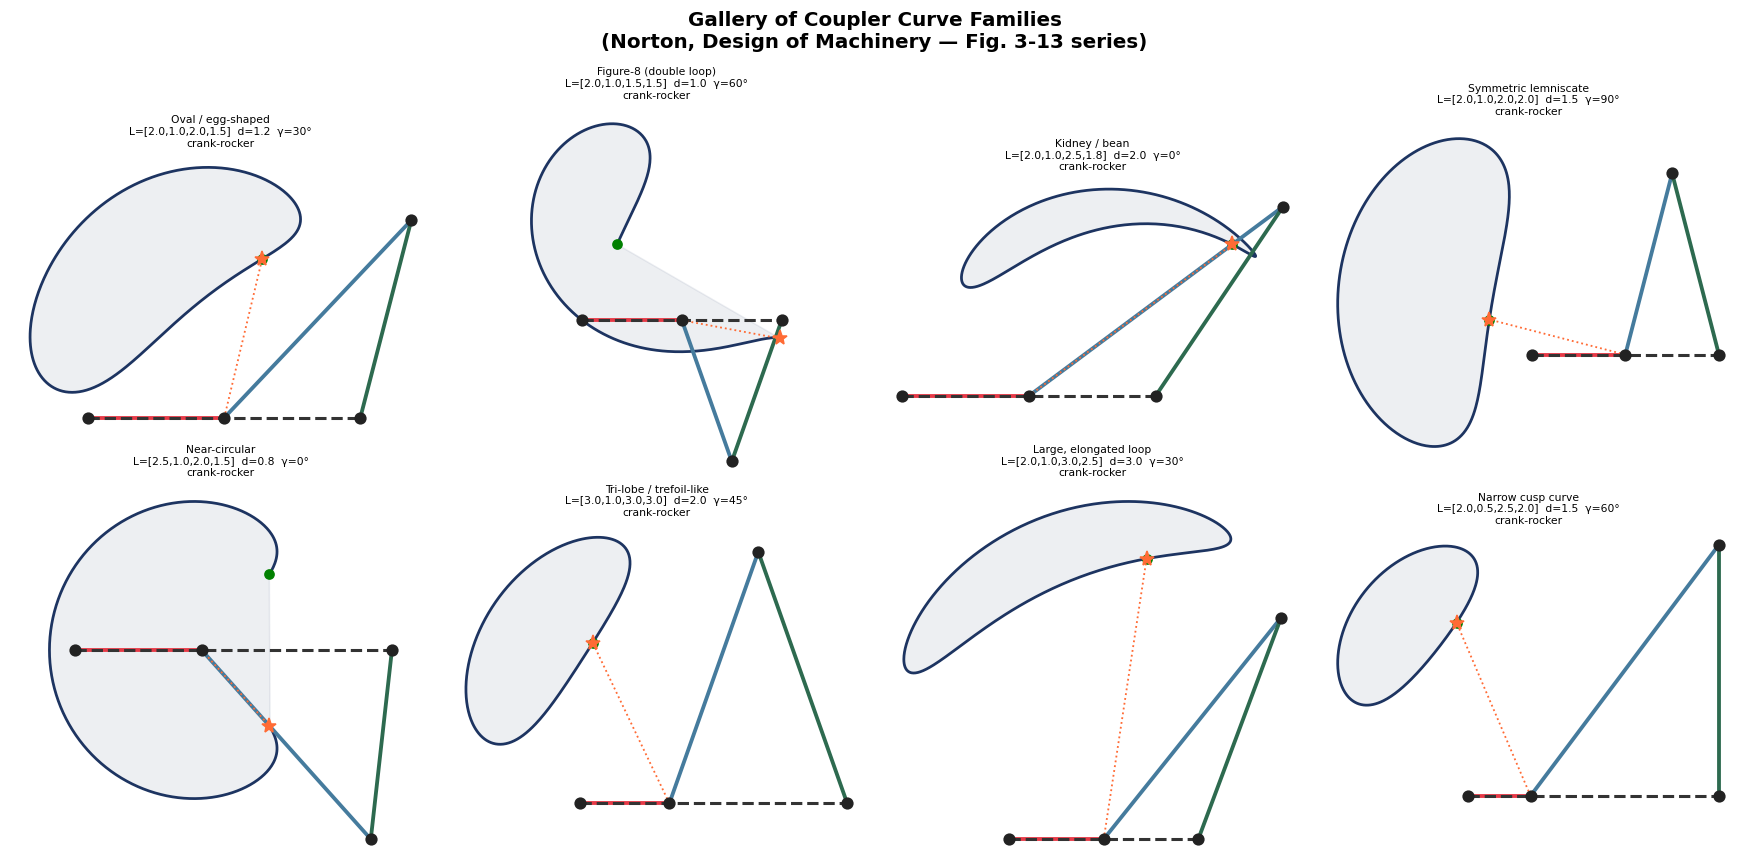

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# Gallery of canonical coupler curve shapes
# Each entry: (L1, L2, L3, L4, d, gamma_deg, label)
# Reference: Norton, Design of Machinery, Fig. 3-13 through 3-22
# ═══════════════════════════════════════════════════════════════════════════════
CANONICAL_MECHS = [
    (2.0, 1.0, 2.0, 1.5, 1.2, 30,  'Oval / egg-shaped'),
    (2.0, 1.0, 1.5, 1.5, 1.0, 60,  'Figure-8 (double loop)'),
    (2.0, 1.0, 2.5, 1.8, 2.0, 0,   'Kidney / bean'),
    (2.0, 1.0, 2.0, 2.0, 1.5, 90,  'Symmetric lemniscate'),
    (2.5, 1.0, 2.0, 1.5, 0.8, 0,   'Near-circular'),
    (3.0, 1.0, 3.0, 3.0, 2.0, 45,  'Tri-lobe / trefoil-like'),
    (2.0, 1.0, 3.0, 2.5, 3.0, 30,  'Large, elongated loop'),
    (2.0, 0.5, 2.5, 2.0, 1.5, 60,  'Narrow cusp curve'),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for idx, (L1, L2, L3, L4, d, gd, label) in enumerate(CANONICAL_MECHS):
    m = FourBar(L1, L2, L3, L4, d=d, gamma=deg2rad(gd))
    gr = m.grashof()
    crv = m.coupler_curve(400)

    ax = axes[idx]
    if len(crv) > 5:
        ax.plot(crv[:, 0], crv[:, 1], lw=1.8, color='#1D3461')
        ax.fill(crv[:, 0], crv[:, 1], alpha=0.08, color='#1D3461')
        # Mark start/end
        ax.plot(*crv[0], 'go', ms=6)
    m.plot_pose(0.0, ax=ax, show_labels=False)
    ax.set_title(f"{label}\n"
                 f"L=[{L1},{L2},{L3},{L4}]  d={d}  γ={gd}°\n"
                 f"{gr['type']}", fontsize=7)
    ax.set_aspect('equal')
    ax.axis('off')

fig.suptitle('Gallery of Coupler Curve Families\n'
             '(Norton, Design of Machinery — Fig. 3-13 series)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# Mechanism animation — crank-rocker example
# ═══════════════════════════════════════════════════════════════════════════════
mech_anim = FourBar(L1=2.0, L2=1.0, L3=2.0, L4=1.5, d=1.2, gamma=deg2rad(30))
crv_full  = mech_anim.coupler_curve(360)

theta2_vals = np.linspace(0, 2 * pi, 120, endpoint=False)

fig_a, ax_a = plt.subplots(figsize=(6, 6))
trace_line, = ax_a.plot([], [], lw=1.5, color='#FF6B35', alpha=0.6,
                         label='Coupler curve (traced)')
crv_bg,     = ax_a.plot(crv_full[:, 0], crv_full[:, 1], '--', lw=0.8,
                         color='#aaaaaa', label='Full curve')

lims = 1.1 * np.array([crv_full[:, 0].min(), crv_full[:, 0].max(),
                        crv_full[:, 1].min(), crv_full[:, 1].max()])
ax_a.set_xlim(lims[0] - 0.3, lims[1] + 0.3)
ax_a.set_ylim(lims[2] - 0.3, lims[3] + 0.3)
ax_a.set_aspect('equal')
ax_a.legend(fontsize=8)

segment_handles = []

def init_anim():
    trace_line.set_data([], [])
    return (trace_line,)

traced_x, traced_y = [], []

def update_anim(i):
    global segment_handles
    for h in segment_handles:
        h.remove()
    segment_handles = []

    th2 = theta2_vals[i]
    pts = mech_anim.joint_positions(th2)
    if not pts['ok']:
        return (trace_line,)

    O2, A, B, O4, P = pts['O2'], pts['A'], pts['B'], pts['O4'], pts['P']
    colors = ['#E63946', '#457B9D', '#2D6A4F', '#888888']
    segs   = [(O2, A), (A, B), (O4, B), (O2, O4)]
    styles = ['-', '-', '-', '--']
    lws    = [3, 2.5, 2.5, 1.5]

    for (p1, p2), c, ls, lw in zip(segs, colors, styles, lws):
        h, = ax_a.plot([p1[0], p2[0]], [p1[1], p2[1]], c=c, ls=ls, lw=lw)
        segment_handles.append(h)

    for p in [O2, A, B, O4]:
        h, = ax_a.plot(*p, 'o', ms=7, color='#222')
        segment_handles.append(h)

    h, = ax_a.plot(*P, '*', ms=12, color='#FF6B35')
    segment_handles.append(h)

    traced_x.append(P[0]); traced_y.append(P[1])
    trace_line.set_data(traced_x, traced_y)

    ax_a.set_title(f'θ₂ = {rad2deg(th2):.1f}°', fontsize=10)
    return (trace_line,)

traced_x.clear(); traced_y.clear()
mech_anim._z0 = np.array([0.3, 2.5])

ani = FuncAnimation(fig_a, update_anim, frames=len(theta2_vals),
                    init_func=init_anim, interval=30, blit=False)
plt.close()
HTML(ani.to_jshtml())

---
## 3. Symmetric mechanisms

A **symmetric four-bar** satisfies $L_2 = L_4$ and $L_1 = L_3$ (or specific ratio conditions). These produce coupler curves symmetric about the perpendicular bisector of the ground link. Norton Fig. 3-21 focuses on this sub-family.

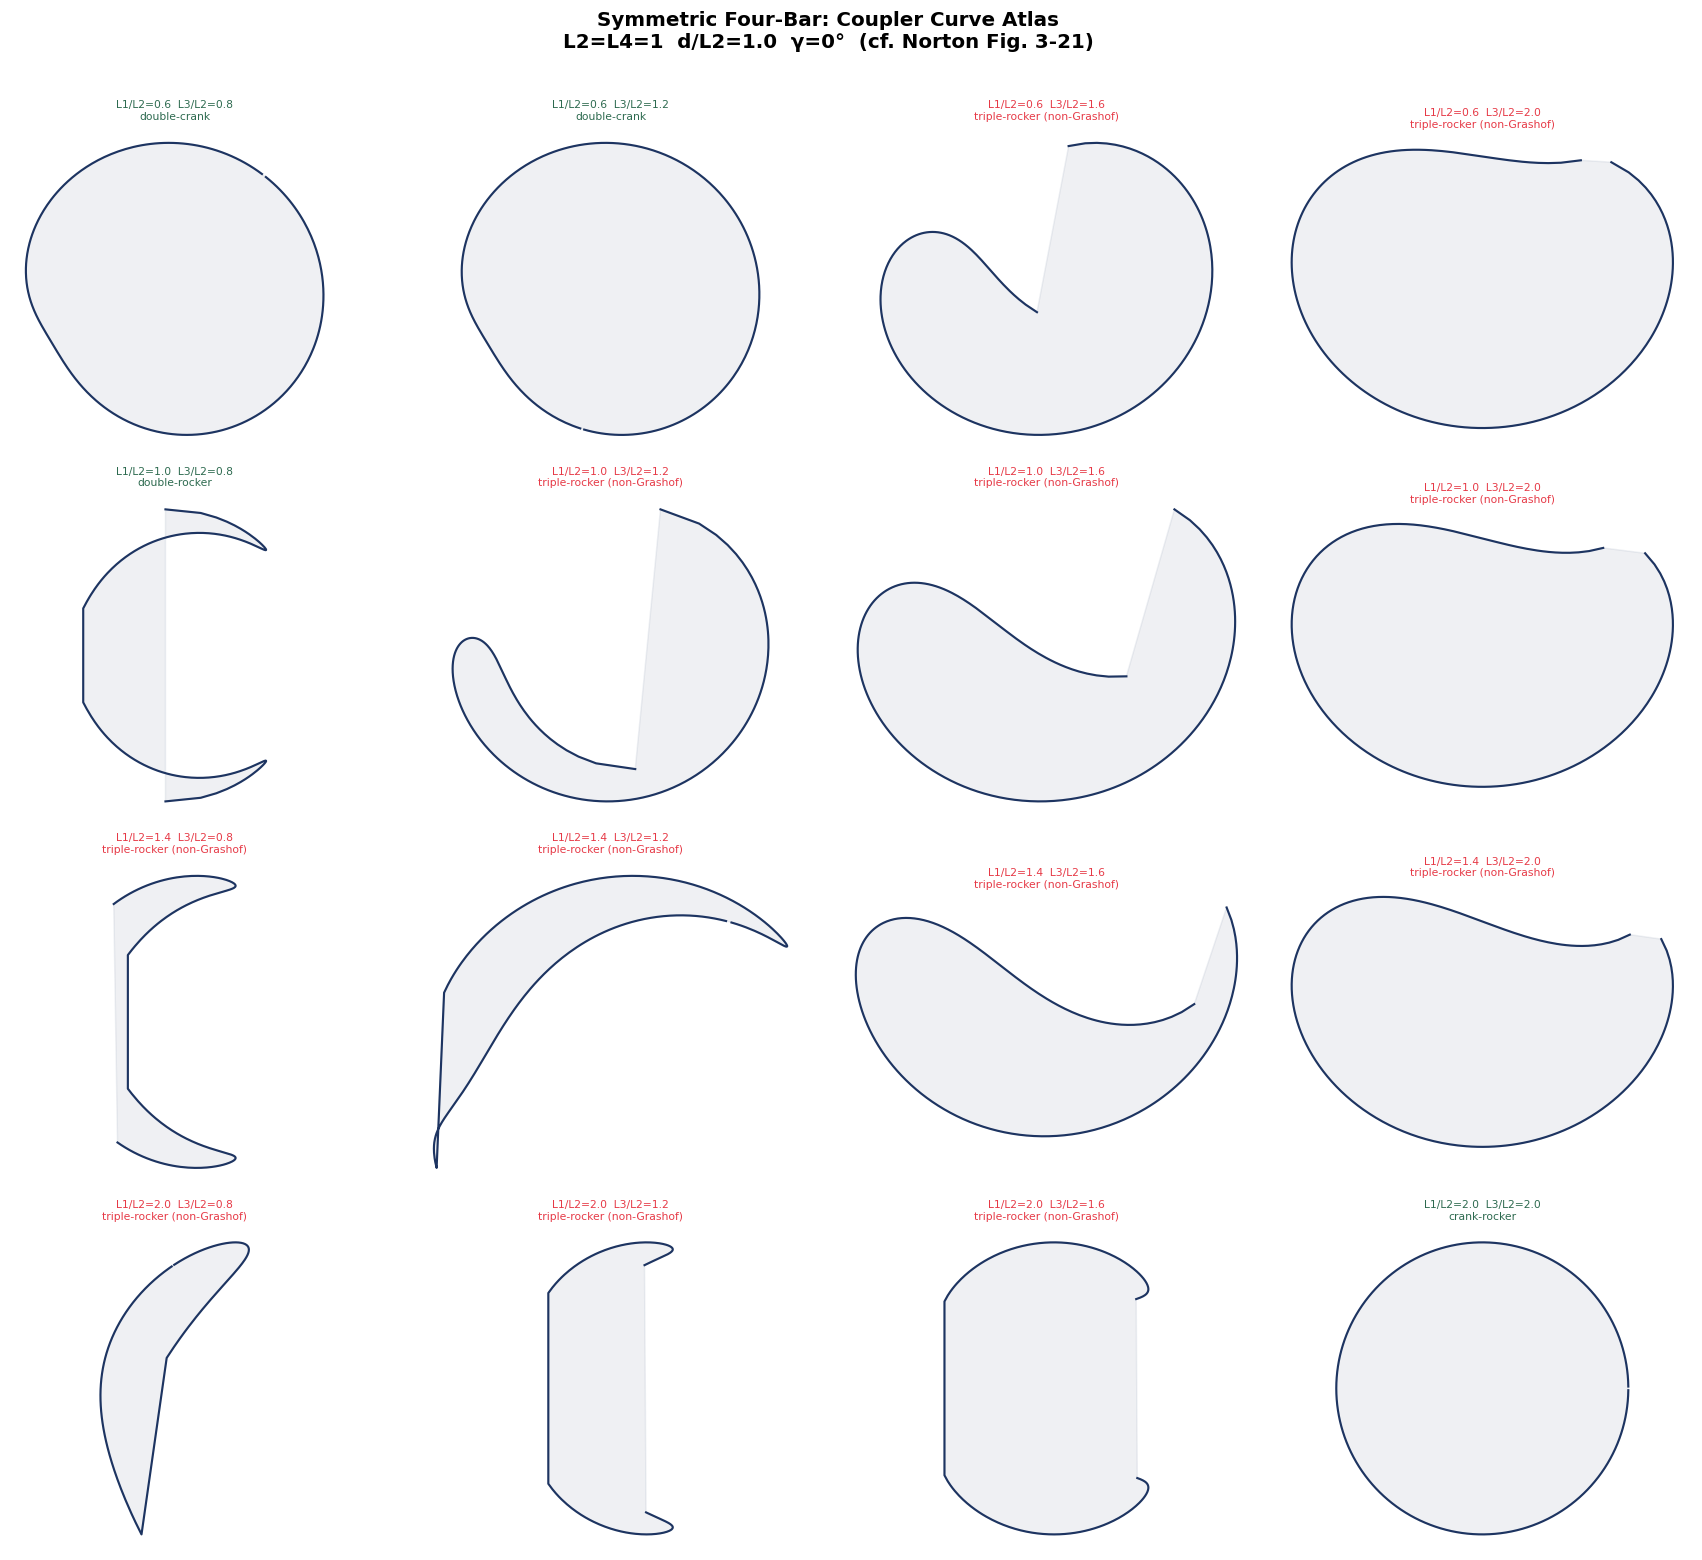

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# Symmetric four-bar family: L2 = L4 = 1 (normalised), L1 varies
# Point P placed symmetrically on the coupler
# Reference: Norton Fig. 3-21
# ═══════════════════════════════════════════════════════════════════════════════

# Norton convention: normalise by L2.  L2 = L4 = 1.  Vary L1/L2 and L3/L2.
L2_n   = 1.0          # normalised crank
d_n    = 1.0          # BP / L2 = 1.0
gamma  = deg2rad(0)   # symmetric placement

L1_ratios = [0.6, 1.0, 1.4, 2.0]
L3_ratios = [0.8, 1.2, 1.6, 2.0]

fig, axes = plt.subplots(len(L1_ratios), len(L3_ratios),
                          figsize=(16, 14))

for ri, L1r in enumerate(L1_ratios):
    for ci, L3r in enumerate(L3_ratios):
        ax = axes[ri][ci]
        L1 = L1r * L2_n
        L3 = L3r * L2_n
        L4 = L2_n          # symmetric: L4 = L2

        m = FourBar(L1, L2_n, L3, L4, d=d_n, gamma=gamma)
        crv = m.coupler_curve(500)
        gr  = m.grashof()

        if len(crv) > 10:
            ax.plot(crv[:, 0] - L1 / 2, crv[:, 1],   # centre the plot
                    lw=1.4, color='#1D3461')
            ax.fill(crv[:, 0] - L1 / 2, crv[:, 1], alpha=0.07, color='#1D3461')
        else:
            ax.text(0.5, 0.5, 'No solution', transform=ax.transAxes,
                    ha='center', fontsize=8, color='red')

        gcolor = '#2D6A4F' if gr['grashof'] else '#E63946'
        ax.set_title(f"L1/L2={L1r}  L3/L2={L3r}\n{gr['type']}",
                     fontsize=7, color=gcolor)
        ax.set_aspect('equal')
        ax.axis('off')

        if ri == 0:
            ax.set_xlabel(f'L3/L2 = {L3r}', fontsize=8)
        if ci == 0:
            ax.set_ylabel(f'L1/L2 = {L1r}', fontsize=8)

fig.suptitle('Symmetric Four-Bar: Coupler Curve Atlas\n'
             f'L2=L4=1  d/L2={d_n}  γ=0°  (cf. Norton Fig. 3-21)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Shape metrics — quantitative classification of coupler curves

We avoid subjective labelling. Instead we compute **eight computable geometric descriptors** from each coupler curve:

| Metric | Symbol | Formula |
|--------|--------|--------|
| Enclosed area | $A$ | Shoelace formula |
| Perimeter | $P_{\text{len}}$ | Sum of chord lengths |
| Compactness (circularity) | $C$ | $4\pi A / P_{\text{len}}^2$ |
| Elongation (PCA ratio) | $E$ | $\lambda_1 / \lambda_2$ |
| Symmetry score | $S$ | Mirror-image Hausdorff normalised |
| Self-intersection count | $N_\times$ | Detected via winding-number test |
| Mean curvature | $\kappa$ | Discrete Menger curvature |
| Bounding box aspect | $R$ | Width / Height of AABB |

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# MODULE: Geometric shape metrics
# ═══════════════════════════════════════════════════════════════════════════════

def _signed_area(curve: np.ndarray) -> float:
    """Signed area via the shoelace formula."""
    x, y = curve[:, 0], curve[:, 1]
    return 0.5 * float(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


def _perimeter(curve: np.ndarray) -> float:
    """Arc-length of the curve (closed polygon)."""
    diffs = np.diff(curve, axis=0, append=curve[:1])
    return float(np.sum(np.linalg.norm(diffs, axis=1)))


def _pca_eigenvalues(curve: np.ndarray) -> np.ndarray:
    """PCA of the point cloud → principal variances."""
    centred = curve - curve.mean(axis=0)
    cov = centred.T @ centred / len(curve)
    vals, _ = np.linalg.eigh(cov)
    return np.sort(vals)[::-1]   # descending


def _symmetry_score(curve: np.ndarray) -> float:
    """
    Bilateral symmetry score.
    We test reflection about the axis connecting the centroid with the
    principal eigenvector.  Score = 1 means perfect symmetry, 0 no symmetry.
    Implemented via Hausdorff distance between curve and its mirror.
    """
    if len(curve) < 5:
        return 0.0
    centred = curve - curve.mean(axis=0)
    # Mirror about x-axis (in principal-component space)
    vals = _pca_eigenvalues(centred)
    if vals[1] < 1e-12:
        return 1.0
    pca = PCA(n_components=2)
    proj = pca.fit_transform(centred)
    mirror = proj.copy(); mirror[:, 1] *= -1
    d1 = directed_hausdorff(proj, mirror)[0]
    d2 = directed_hausdorff(mirror, proj)[0]
    scale = np.max(np.abs(proj))
    return float(max(0.0, 1.0 - max(d1, d2) / (scale + 1e-12)))


def _count_self_intersections(curve: np.ndarray) -> int:
    """
    Approximate count of self-intersections via segment crossing test.
    Uses cross-product sign changes; O(n²) so kept for small n.
    """
    n = len(curve)
    if n < 6:
        return 0
    count = 0
    # Sub-sample for speed if too many points
    step = max(1, n // 80)
    c = curve[::step]
    m = len(c)

    def ccw(A, B, C):
        return (C[1]-A[1]) * (B[0]-A[0]) > (B[1]-A[1]) * (C[0]-A[0])

    def intersects(A, B, C, D):
        return (ccw(A, C, D) != ccw(B, C, D)) and (ccw(A, B, C) != ccw(A, B, D))

    for i in range(m - 1):
        for j in range(i + 2, m - 1):
            if i == 0 and j == m - 2:
                continue   # skip closing segment
            if intersects(c[i], c[i+1], c[j], c[j+1]):
                count += 1
    return count


def _mean_curvature(curve: np.ndarray) -> float:
    """
    Mean absolute discrete curvature (Menger curvature at each triple of points).
    κ = 4·Area(triangle) / (|AB|·|BC|·|CA|)
    """
    if len(curve) < 3:
        return 0.0
    kappas = []
    n = len(curve)
    for i in range(n):
        A = curve[i]
        B = curve[(i + 1) % n]
        C = curve[(i + 2) % n]
        area = abs(0.5 * ((B[0]-A[0])*(C[1]-A[1]) - (C[0]-A[0])*(B[1]-A[1])))
        d = (np.linalg.norm(B - A) * np.linalg.norm(C - B) *
             np.linalg.norm(A - C))
        if d > 1e-14:
            kappas.append(4 * area / d)
    return float(np.mean(kappas)) if kappas else 0.0


def compute_shape_metrics(curve: np.ndarray) -> dict:
    """
    Compute all geometric descriptors for a coupler curve.

    Parameters
    ----------
    curve : (N, 2) array of (x, y) positions

    Returns
    -------
    dict of scalar metrics
    """
    if len(curve) < 5:
        return {k: np.nan for k in ['area', 'perimeter', 'circularity',
                                     'elongation', 'symmetry',
                                     'self_intersections', 'mean_curvature',
                                     'aspect_ratio', 'pca_eig1', 'pca_eig2']}
    area    = abs(_signed_area(curve))
    perim   = _perimeter(curve)
    circ    = 4 * pi * area / (perim ** 2 + 1e-14)
    eigs    = _pca_eigenvalues(curve)
    elong   = float(np.sqrt(eigs[0] / (eigs[1] + 1e-14)))
    sym     = _symmetry_score(curve)
    n_cross = _count_self_intersections(curve)
    kappa   = _mean_curvature(curve)
    bbox    = (curve.max(axis=0) - curve.min(axis=0))
    aspect  = float(bbox[0] / (bbox[1] + 1e-14))

    return {
        'area':               area,
        'perimeter':          perim,
        'circularity':        min(circ, 1.0),
        'elongation':         elong,
        'symmetry':           sym,
        'self_intersections': n_cross,
        'mean_curvature':     kappa,
        'aspect_ratio':       aspect,
        'pca_eig1':           float(eigs[0]),
        'pca_eig2':           float(eigs[1]),
    }


# ── Test on canonical mechanisms ──────────────────────────────────────────────
print(f"{'Label':<30} {'Area':>8} {'Circ':>6} {'Elong':>7} {'Sym':>6} {'Nx':>4} {'κ':>8}")
print('-' * 75)
for L1, L2, L3, L4, d, gd, label in CANONICAL_MECHS:
    m   = FourBar(L1, L2, L3, L4, d=d, gamma=deg2rad(gd))
    crv = m.coupler_curve(360)
    met = compute_shape_metrics(crv)
    print(f"{label:<30} {met['area']:>8.3f} {met['circularity']:>6.3f} "
          f"{met['elongation']:>7.2f} {met['symmetry']:>6.3f} "
          f"{met['self_intersections']:>4d} {met['mean_curvature']:>8.4f}")

Label                              Area   Circ   Elong    Sym   Nx        κ
---------------------------------------------------------------------------
Oval / egg-shaped                 1.877  0.767    2.09  0.812    0   1.5466
Figure-8 (double loop)            2.554  0.497    1.75  0.434    0   8.8782
Kidney / bean                     0.628  0.281    3.75  0.678    0   5.3353
Symmetric lemniscate              4.504  0.825    1.91  0.830    0   0.9410
Near-circular                     3.433  0.915    1.37  0.468    0   1.4878
Tri-lobe / trefoil-like           2.516  0.776    2.23  0.874    0   1.2734
Large, elongated loop             2.285  0.422    3.69  0.747    0   1.8466
Narrow cusp curve                 0.879  0.830    2.00  0.903    0   2.0831


---
## 5. Parametric sweep — Norton/Kota 2D design maps

We systematically sweep the normalised link ratios $(L_3/L_2,\; L_1/L_2)$ at fixed $L_4/L_2$ and $d/L_2$, generating a library of coupler curves — analogous to Norton's Fig. 3-21/3-22 and Kota's design atlas.

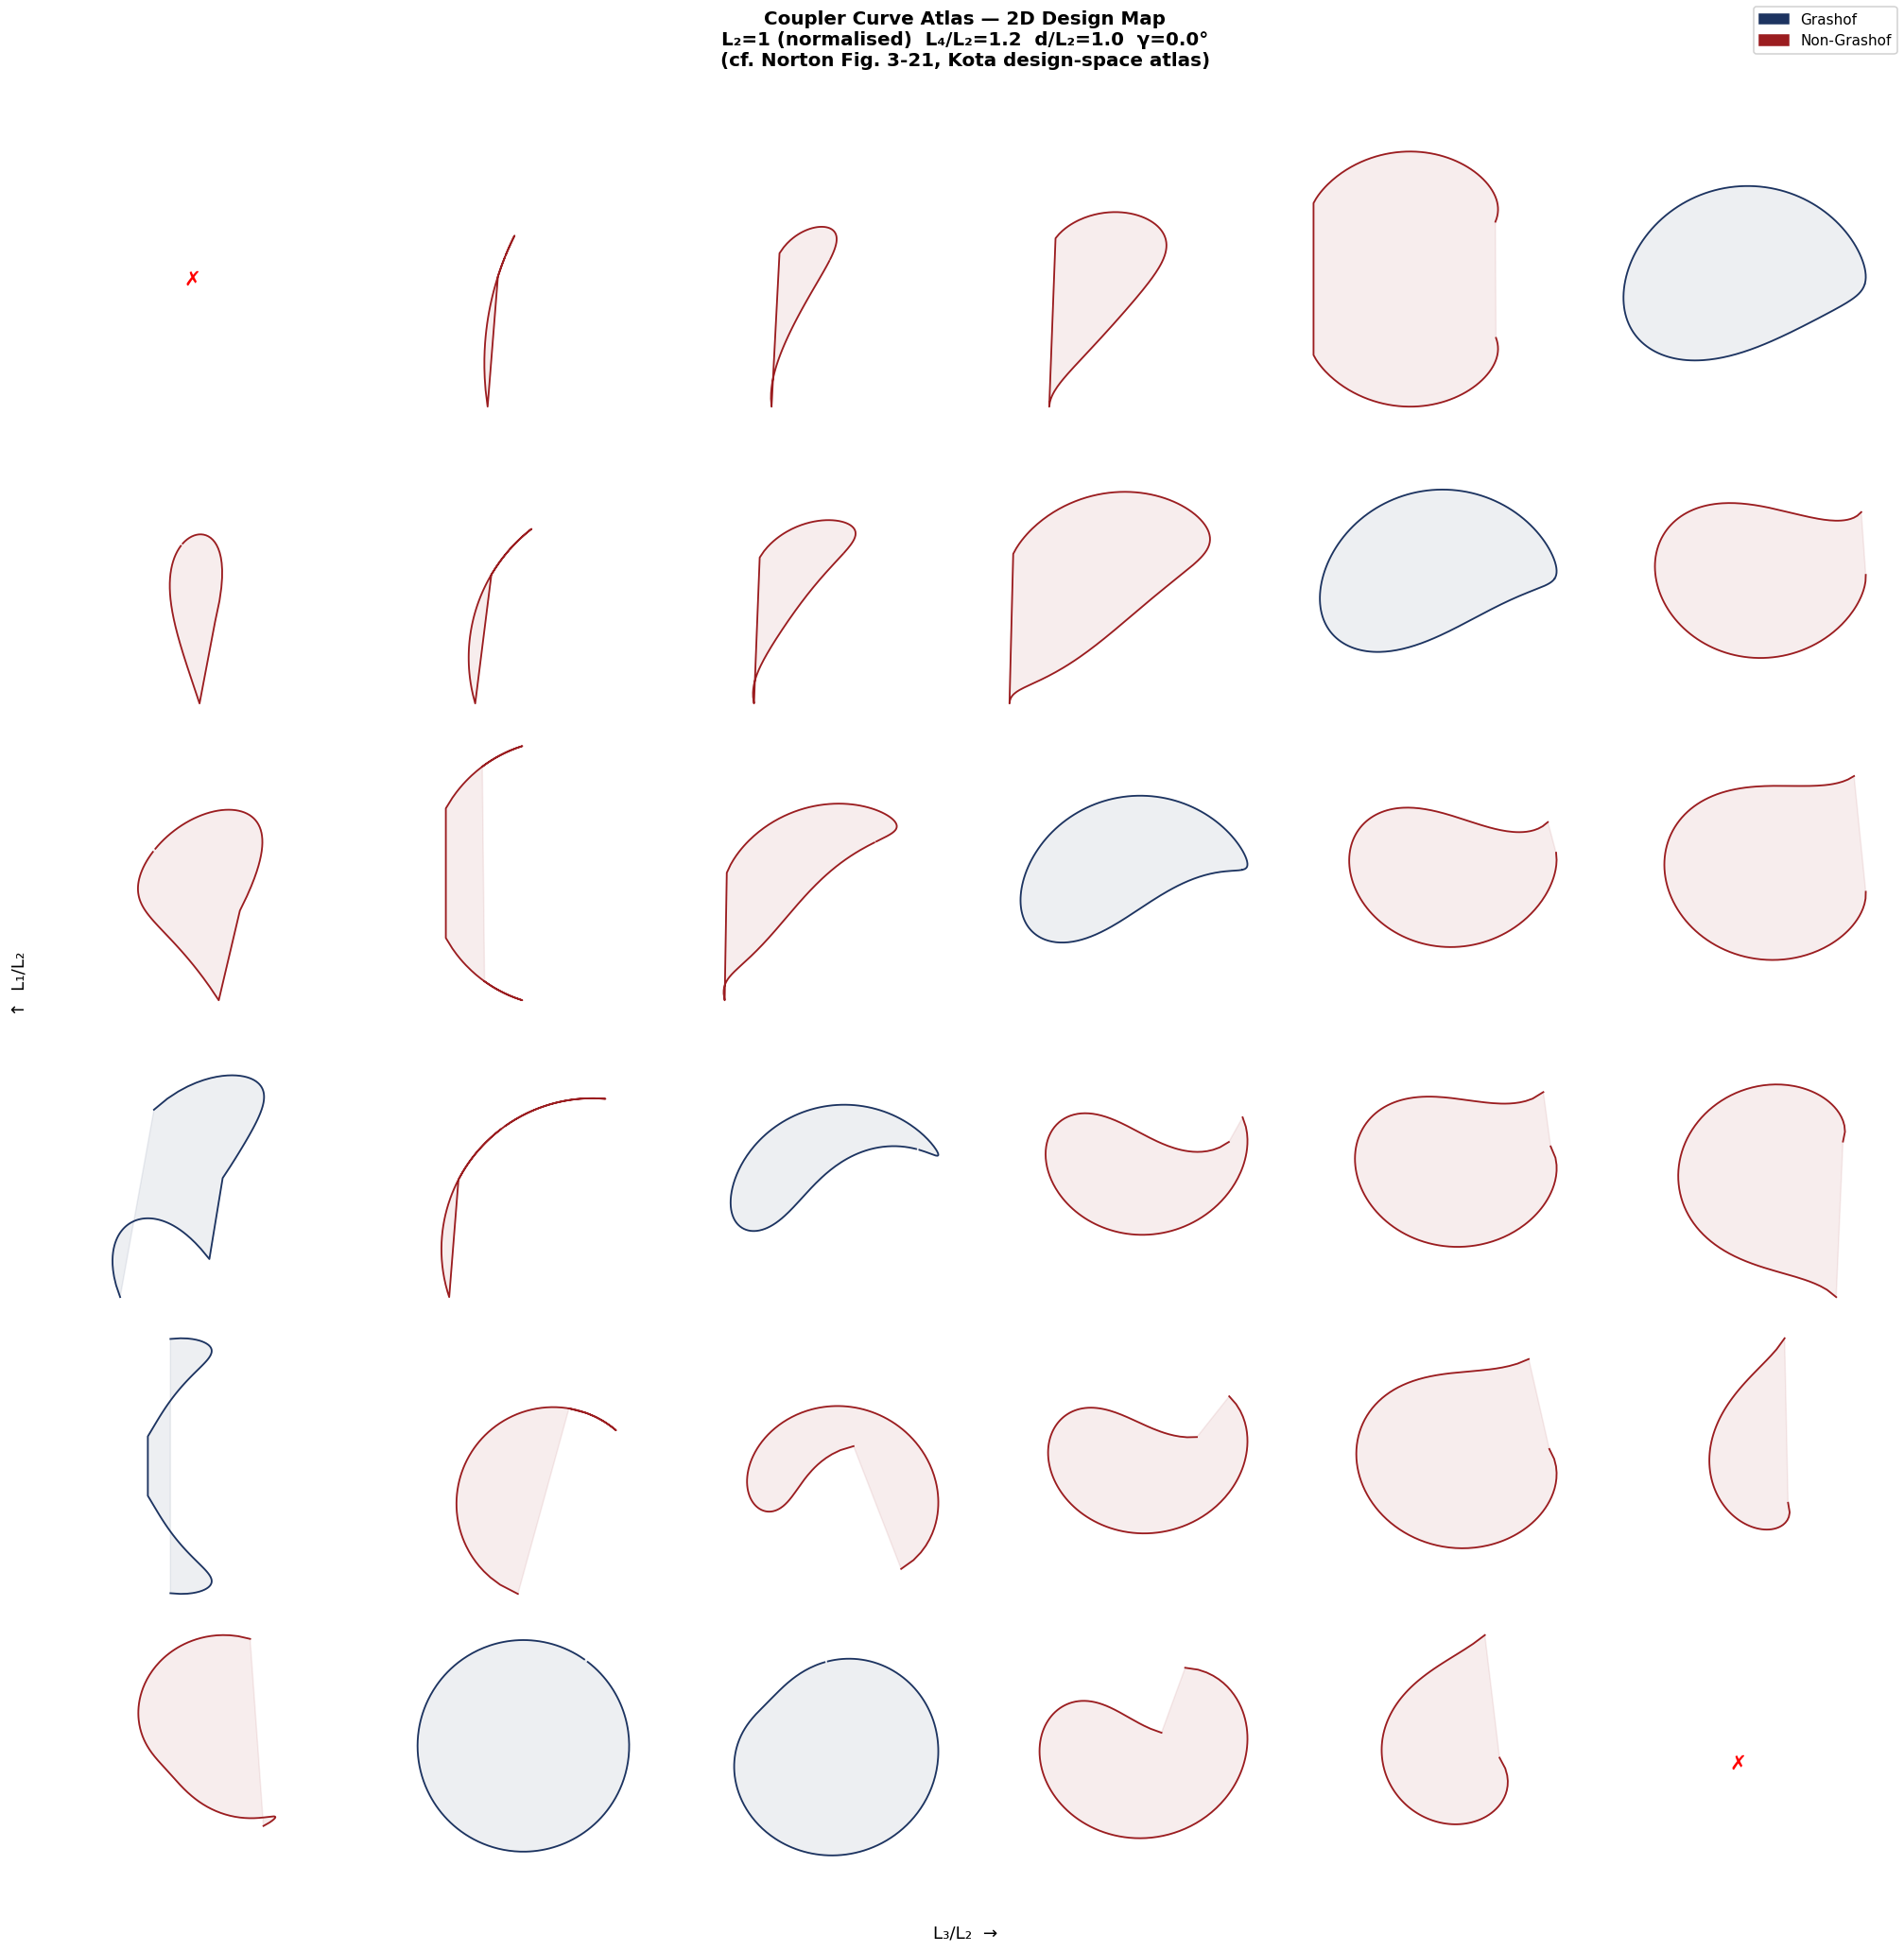

Generated 36 mechanisms


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# Parametric sweep over (L1/L2, L3/L2) — 2D design atlas
# Fixed: L2=1 (normalised), L4/L2=1.2, d/L2=1.0, gamma=0
# ═══════════════════════════════════════════════════════════════════════════════
SWEEP_N      = 6       # grid resolution (increase to 8-10 for publication)
L2_BASE      = 1.0
L4_RATIO     = 1.2
D_RATIO      = 1.0
GAMMA_DEG    = 0.0

L1_sweep = np.linspace(0.5, 3.0, SWEEP_N)
L3_sweep = np.linspace(0.5, 3.0, SWEEP_N)

fig_atlas, axes_atlas = plt.subplots(SWEEP_N, SWEEP_N,
                                      figsize=(3 * SWEEP_N, 3 * SWEEP_N))

atlas_data = []   # store (L1r, L3r, metrics, curve) for later analysis

for ri, L1r in enumerate(L1_sweep[::-1]):   # top row = large L1
    for ci, L3r in enumerate(L3_sweep):
        ax = axes_atlas[ri][ci]

        L1 = L1r * L2_BASE
        L3 = L3r * L2_BASE
        L4 = L4_RATIO * L2_BASE
        d  = D_RATIO  * L2_BASE

        m   = FourBar(L1, L2_BASE, L3, L4, d=d, gamma=deg2rad(GAMMA_DEG))
        crv = m.coupler_curve(300)
        gr  = m.grashof()
        met = compute_shape_metrics(crv)

        atlas_data.append({
            'L1r': L1r, 'L3r': L3r, 'grashof': gr['grashof'],
            'type': gr['type'], 'n_pts': len(crv), **met
        })

        if len(crv) > 10:
            cx = crv[:, 0] - crv[:, 0].mean()
            cy = crv[:, 1] - crv[:, 1].mean()
            scale = max(np.abs(cx).max(), np.abs(cy).max()) + 1e-9
            color = '#1D3461' if gr['grashof'] else '#9B1D20'
            ax.plot(cx / scale, cy / scale, lw=1.2, color=color)
            ax.fill(cx / scale, cy / scale, alpha=0.08, color=color)
        else:
            ax.set_facecolor('#f5e6e6')
            ax.text(0.5, 0.5, '✗', transform=ax.transAxes,
                    ha='center', va='center', color='red', fontsize=14)

        ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
        ax.set_aspect('equal'); ax.axis('off')

        if ri == SWEEP_N - 1:
            ax.set_xlabel(f'{L3r:.1f}', fontsize=8)
        if ci == 0:
            ax.set_ylabel(f'{L1r:.1f}', fontsize=8)

# Row/column labels
fig_atlas.text(0.5, -0.01, 'L₃/L₂  →', ha='center', fontsize=12)
fig_atlas.text(-0.01, 0.5, '↑  L₁/L₂', va='center', rotation='vertical', fontsize=12)

# Legend
blue_p = mpatches.Patch(color='#1D3461', label='Grashof')
red_p  = mpatches.Patch(color='#9B1D20', label='Non-Grashof')
fig_atlas.legend(handles=[blue_p, red_p], loc='upper right',
                 fontsize=10, framealpha=0.9)

fig_atlas.suptitle(
    f'Coupler Curve Atlas — 2D Design Map\n'
    f'L₂=1 (normalised)  L₄/L₂={L4_RATIO}  d/L₂={D_RATIO}  γ={GAMMA_DEG}°\n'
    f'(cf. Norton Fig. 3-21, Kota design-space atlas)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()
print(f"Generated {len(atlas_data)} mechanisms")

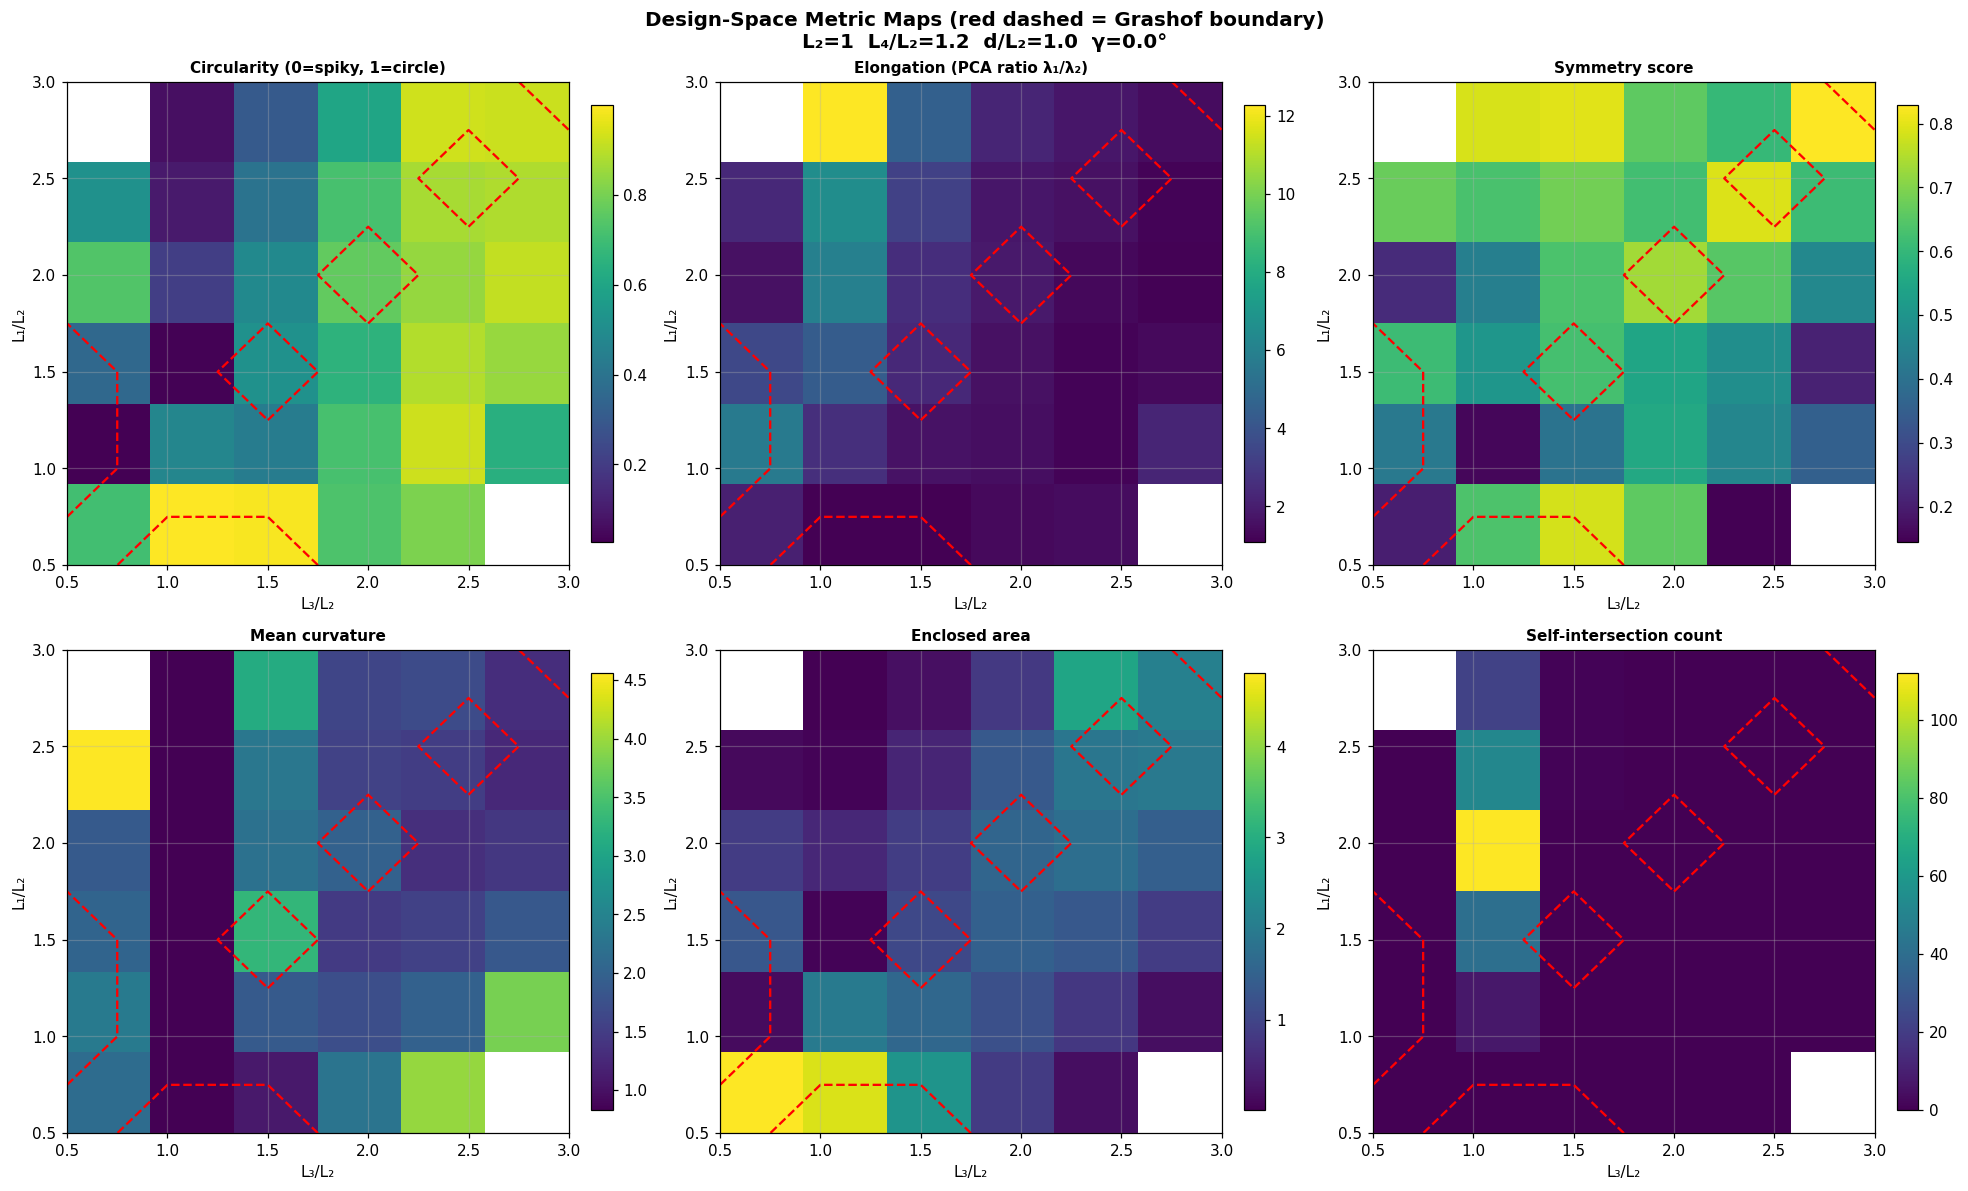

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2D metric maps — colour-coded by shape property
# This gives a quantitative "landscape" of the design space,
# analogous to Norton Fig. 3-22
# ═══════════════════════════════════════════════════════════════════════════════
import pandas as pd

df = pd.DataFrame(atlas_data).replace([np.inf, -np.inf], np.nan)

metrics_to_plot = ['circularity', 'elongation', 'symmetry',
                   'mean_curvature', 'area', 'self_intersections']
metric_labels   = ['Circularity (0=spiky, 1=circle)',
                   'Elongation (PCA ratio λ₁/λ₂)',
                   'Symmetry score',
                   'Mean curvature',
                   'Enclosed area',
                   'Self-intersection count']

fig_maps, axes_m = plt.subplots(2, 3, figsize=(18, 11))
axes_m = axes_m.ravel()

for idx, (met, label) in enumerate(zip(metrics_to_plot, metric_labels)):
    ax = axes_m[idx]
    pivot = df.pivot_table(index='L1r', columns='L3r', values=met)
    pivot = pivot.sort_index(ascending=True)

    vals = pivot.values.astype(float)
    im = ax.imshow(vals, origin='lower', aspect='auto',
                   cmap='viridis',
                   extent=[L3_sweep[0], L3_sweep[-1],
                           L1_sweep[0], L1_sweep[-1]])
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
    ax.set_xlabel('L₃/L₂', fontsize=10)
    ax.set_ylabel('L₁/L₂', fontsize=10)
    ax.set_title(label, fontsize=10, fontweight='bold')

    # Grashof boundary overlay
    grashof_mask = df.pivot_table(index='L1r', columns='L3r',
                                   values='grashof').sort_index(ascending=True)
    ax.contour(L3_sweep, L1_sweep,
               grashof_mask.values.astype(float),
               levels=[0.5], colors='red', linewidths=1.5,
               linestyles='--')

fig_maps.suptitle('Design-Space Metric Maps (red dashed = Grashof boundary)\n'
                  f'L₂=1  L₄/L₂={L4_RATIO}  d/L₂={D_RATIO}  γ={GAMMA_DEG}°',
                  fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Large-scale parametric sweep & 3D design space

We now sweep **all five parameters** $(L_1, L_3, L_4, d, \gamma)$ (with $L_2 = 1$ normalised), compute the shape metric vector for each mechanism, reduce dimensionality with PCA, cluster, and visualise the 3D design space.

In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# Large parametric sweep — 5D parameter space
# Generates a library of mechanisms and their shape fingerprints
# ═══════════════════════════════════════════════════════════════════════════════

N_SWEEP = 8        # points per axis (N^5 total — keep manageable)
L2_N    = 1.0      # always normalised

# Parameter ranges (normalised by L2)
L1_range    = np.linspace(0.5, 3.0, N_SWEEP)
L3_range    = np.linspace(0.5, 3.0, N_SWEEP)
L4_range    = np.linspace(0.5, 2.0, 4)
d_range     = np.linspace(0.3, 2.0, 4)
gamma_range = deg2rad(np.linspace(0, 90, 4))

print(f"Sweeping {N_SWEEP}×{N_SWEEP}×4×4×4 = "
      f"{N_SWEEP**2 * 4**3:,} parameter combinations …", end=' ')
t0 = time.time()

library = []   # list of dicts: params + metrics

for L1r, L3r, L4r, dr, gam in itertools.product(
        L1_range, L3_range, L4_range, d_range, gamma_range):

    L1 = L1r * L2_N
    L3 = L3r * L2_N
    L4 = L4r * L2_N
    d  = dr  * L2_N

    m   = FourBar(L1, L2_N, L3, L4, d=d, gamma=gam)
    crv = m.coupler_curve(200)           # 200 pts is enough for metrics
    gr  = m.grashof()

    if len(crv) < 20:
        continue

    met = compute_shape_metrics(crv)
    if any(np.isnan(v) for v in met.values()):
        continue

    library.append({
        'L1r': L1r, 'L3r': L3r, 'L4r': L4r, 'dr': dr, 'gamma_deg': rad2deg(gam),
        'grashof': gr['grashof'], 'mech_type': gr['type'],
        **met
    })

print(f"done in {time.time()-t0:.1f}s  →  {len(library):,} valid mechanisms")
df_lib = pd.DataFrame(library)

Sweeping 8×8×4×4×4 = 4,096 parameter combinations … done in 285.6s  →  3,696 valid mechanisms


In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# PCA + K-Means clustering of shape-metric fingerprints
# Reference: Kota (1992) — design-space topology via feature clustering
# ═══════════════════════════════════════════════════════════════════════════════

METRIC_COLS = ['circularity', 'elongation', 'symmetry',
               'mean_curvature', 'area', 'aspect_ratio',
               'pca_eig1', 'pca_eig2']

X_raw = df_lib[METRIC_COLS].values.astype(float)

# Normalise — each metric on its own scale
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# PCA to 3D (for visualisation) and retain explained variance
pca3 = PCA(n_components=3)
X_pca = pca3.fit_transform(X_scaled)

print(f"PCA explained variance: "
      f"PC1={pca3.explained_variance_ratio_[0]:.1%}  "
      f"PC2={pca3.explained_variance_ratio_[1]:.1%}  "
      f"PC3={pca3.explained_variance_ratio_[2]:.1%}  "
      f"Total={sum(pca3.explained_variance_ratio_):.1%}")

# K-Means clustering (k=6 — corresponds to major shape families)
N_CLUSTERS = 6
kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=20, random_state=42)
labels = kmeans.fit_predict(X_scaled)
df_lib['cluster'] = labels
df_lib['pc1'] = X_pca[:, 0]
df_lib['pc2'] = X_pca[:, 1]
df_lib['pc3'] = X_pca[:, 2]

# Print cluster statistics
print(f"\nCluster populations:")
for k in range(N_CLUSTERS):
    mask = labels == k
    sub  = df_lib[mask]
    print(f"  Cluster {k}: n={mask.sum():5d}  "
          f"circ={sub['circularity'].mean():.3f}  "
          f"elong={sub['elongation'].mean():.2f}  "
          f"sym={sub['symmetry'].mean():.3f}  "
          f"Nx={sub['self_intersections'].mean():.1f}")

PCA explained variance: PC1=37.1%  PC2=17.2%  PC3=13.7%  Total=68.1%

Cluster populations:
  Cluster 0: n=  836  circ=0.299  elong=5.29  sym=0.624  Nx=0.4
  Cluster 1: n=  808  circ=0.878  elong=1.57  sym=0.814  Nx=0.0
  Cluster 2: n=   87  circ=0.095  elong=23.34  sym=0.879  Nx=0.6
  Cluster 3: n=  456  circ=0.299  elong=3.03  sym=0.564  Nx=0.4
  Cluster 4: n= 1261  circ=0.708  elong=2.17  sym=0.385  Nx=0.1
  Cluster 5: n=  248  circ=0.689  elong=2.08  sym=0.429  Nx=0.1


In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3D interactive design-space map — Plotly
# Axes: PC1, PC2, PC3 (shape-space coordinates)
# Colour: cluster label;  symbol: Grashof / non-Grashof
# ═══════════════════════════════════════════════════════════════════════════════
CLUSTER_NAMES = [
    'C0: Compact/circular',
    'C1: Elongated oval',
    'C2: Symmetric lemniscate',
    'C3: Self-intersecting',
    'C4: Large-area loop',
    'C5: Irregular/complex',
]
PALETTE = ['#1D3461', '#E63946', '#2D6A4F', '#FF6B35', '#9B1D20', '#6B4226', '#457B9D', '#F4A261']

if PLOTLY_OK:
    fig3d = go.Figure()

    for k in range(N_CLUSTERS):
        mask = df_lib['cluster'] == k
        sub  = df_lib[mask]

        # Hover text
        hover = [
            f"L1/L2={r.L1r:.2f}  L3/L2={r.L3r:.2f}  L4/L2={r.L4r:.2f}<br>"
            f"d/L2={r.dr:.2f}  γ={r.gamma_deg:.0f}°<br>"
            f"Grashof: {r.grashof}<br>"
            f"Circ={r.circularity:.3f}  Elong={r.elongation:.2f}<br>"
            f"Sym={r.symmetry:.3f}  Nx={int(r.self_intersections)}"
            for r in sub.itertuples()
        ]

        fig3d.add_trace(go.Scatter3d(
            x=sub['pc1'], y=sub['pc2'], z=sub['pc3'],
            mode='markers',
            marker=dict(
                size=3,
                color=PALETTE[k % len(PALETTE)],
                opacity=0.6,
                symbol=np.where(sub['grashof'], 'circle', 'x').tolist()
            ),
            name=CLUSTER_NAMES[k] if k < len(CLUSTER_NAMES) else f'Cluster {k}',
            text=hover, hovertemplate='%{text}<extra></extra>'
        ))

    # Cluster centroids
    cen_pca = pca3.transform(scaler.transform(kmeans.cluster_centers_))
    fig3d.add_trace(go.Scatter3d(
        x=cen_pca[:, 0], y=cen_pca[:, 1], z=cen_pca[:, 2],
        mode='markers+text',
        marker=dict(size=12, color='black', symbol='diamond'),
        text=[f'C{k}' for k in range(N_CLUSTERS)],
        textposition='top center',
        name='Centroids', showlegend=True
    ))

    ev = pca3.explained_variance_ratio_
    fig3d.update_layout(
        title=dict(
            text='3D Coupler-Curve Design Space<br>'
                 '<sub>(axes = PCA of shape metrics; ● Grashof  ✕ non-Grashof)</sub>',
            x=0.5
        ),
        scene=dict(
            xaxis_title=f'PC1 ({ev[0]:.1%})',
            yaxis_title=f'PC2 ({ev[1]:.1%})',
            zaxis_title=f'PC3 ({ev[2]:.1%})',
        ),
        legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.8)'),
        width=950, height=700,
    )
    fig3d.show()
else:
    # Matplotlib fallback
    fig = plt.figure(figsize=(10, 8))
    ax3 = fig.add_subplot(111, projection='3d')
    for k in range(N_CLUSTERS):
        mask = df_lib['cluster'] == k
        sub  = df_lib[mask]
        ax3.scatter(sub['pc1'], sub['pc2'], sub['pc3'],
                    s=5, alpha=0.4, label=f'Cluster {k}')
    ax3.set_xlabel('PC1'); ax3.set_ylabel('PC2'); ax3.set_zlabel('PC3')
    ax3.legend(fontsize=8)
    plt.title('3D Design Space (PCA of shape metrics)')
    plt.tight_layout()
    plt.show()

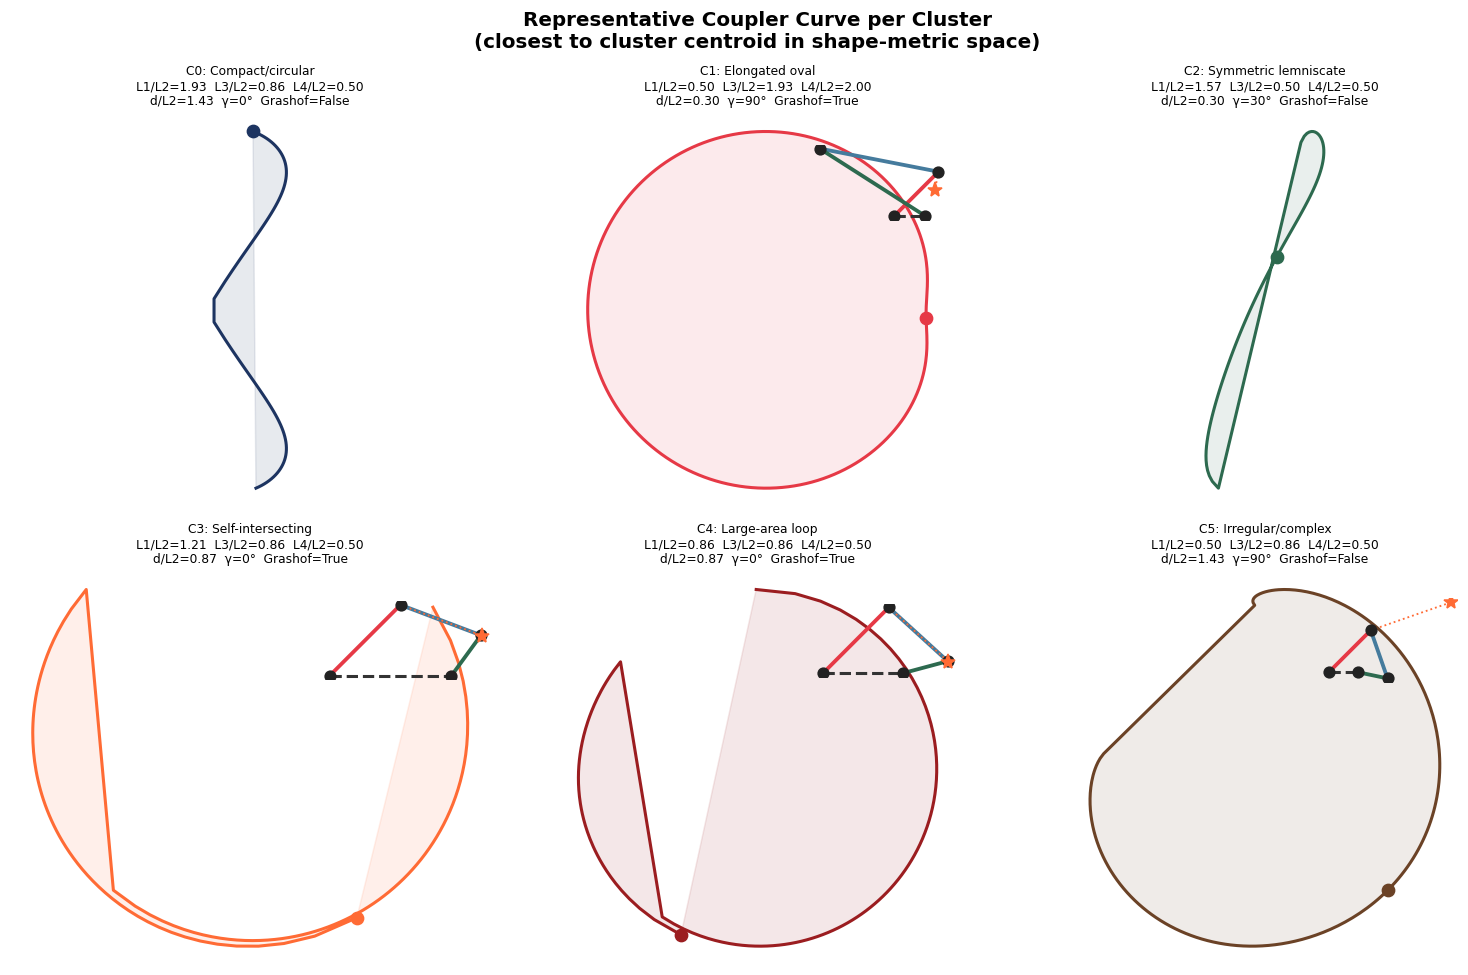

In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# Representative coupler curves per cluster
# ═══════════════════════════════════════════════════════════════════════════════

fig_cl, axes_cl = plt.subplots(2, 3, figsize=(14, 9))
axes_cl = axes_cl.ravel()

for k in range(N_CLUSTERS):
    mask = df_lib['cluster'] == k
    sub  = df_lib[mask]

    # Centroid row in original space — pick the actual mechanism closest to it
    X_sub    = scaler.transform(sub[METRIC_COLS].values)
    centroid = scaler.transform(kmeans.cluster_centers_[[k]])
    dists    = np.linalg.norm(X_sub - centroid, axis=1)
    rep_idx  = sub.index[np.argmin(dists)]
    row      = df_lib.loc[rep_idx]

    m   = FourBar(row.L1r, L2_N, row.L3r, row.L4r * L2_N,
                  d=row.dr * L2_N, gamma=deg2rad(row.gamma_deg))
    crv = m.coupler_curve(400)

    ax = axes_cl[k]
    if len(crv) > 5:
        cx = crv[:, 0] - crv[:, 0].mean()
        cy = crv[:, 1] - crv[:, 1].mean()
        color = PALETTE[k % len(PALETTE)]
        ax.plot(cx, cy, lw=2, color=color)
        ax.fill(cx, cy, alpha=0.1, color=color)
        ax.plot(*[cx[0], cy[0]], 'o', color=color, ms=8)

    title = (CLUSTER_NAMES[k] if k < len(CLUSTER_NAMES) else f'Cluster {k}')
    ax.set_title(f'{title}\n'
                 f'L1/L2={row.L1r:.2f}  L3/L2={row.L3r:.2f}  '
                 f'L4/L2={row.L4r:.2f}\n'
                 f'd/L2={row.dr:.2f}  γ={row.gamma_deg:.0f}°  '
                 f'Grashof={row.grashof}', fontsize=8)
    ax.set_aspect('equal')
    ax.axis('off')

    # Inset: mechanism sketch
    axins = ax.inset_axes([0.65, 0.65, 0.35, 0.35])
    m2 = FourBar(row.L1r, L2_N, row.L3r, row.L4r * L2_N,
                 d=row.dr * L2_N, gamma=deg2rad(row.gamma_deg))
    m2.plot_pose(deg2rad(45), ax=axins, show_labels=False)
    axins.axis('off')

fig_cl.suptitle('Representative Coupler Curve per Cluster\n'
                '(closest to cluster centroid in shape-metric space)',
                fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Trajectory synthesis — automatic mechanism design

Given a **target path** $\{(x_i^*, y_i^*)\}$, we seek mechanism parameters $(L_1, L_2, L_3, L_4, d, \gamma)$ that minimise the distance between the coupler curve and the target.

### Objective function

$$\mathcal{F}(\mathbf{p}) = w_1 \cdot e_{\text{Hausdorff}} + w_2 \cdot e_{\text{Procrustes}} + w_3 \cdot e_{\text{RMS}} \tag{3}$$

where:
- $e_{\text{Hausdorff}}$: max-min distance (shape boundary matching)
- $e_{\text{Procrustes}}$: shape-only error after optimal rigid transform
- $e_{\text{RMS}}$: RMS point-to-nearest-point distance (after Procrustes alignment)

All three are normalised by the target curve's scale (diameter of bounding circle).

### Procrustes alignment

The synthesised curve and target may differ in translation, rotation, and scale. We remove these using the **Procrustes superimposition**:

$$\min_{R, s, t} \| s \cdot R \cdot X - Y \|_F^2$$

where $R$ is a rotation, $s$ is scale, and $t$ is translation (applied after centering).

In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# MODULE: Synthesis objective function
# ═══════════════════════════════════════════════════════════════════════════════

def _resample_curve(curve: np.ndarray, n: int = 100) -> np.ndarray:
    """
    Resample a curve to exactly n equi-arc-length points.
    Uses linear interpolation along the cumulative arc-length.
    """
    if len(curve) < 2:
        return curve
    # Close the curve
    closed = np.vstack([curve, curve[:1]])
    dists  = np.linalg.norm(np.diff(closed, axis=0), axis=1)
    cum    = np.concatenate([[0], np.cumsum(dists)])
    total  = cum[-1]
    if total < 1e-12:
        return curve[:1]
    t_new  = np.linspace(0, total, n, endpoint=False)
    xs = np.interp(t_new, cum, closed[:, 0])
    ys = np.interp(t_new, cum, closed[:, 1])
    return np.column_stack([xs, ys])


def _procrustes_align(source: np.ndarray, target: np.ndarray
                       ) -> tuple:
    """
    Align *source* to *target* using Procrustes superimposition.
    Both are (N, 2) arrays.  Returns (aligned_source, procrustes_error).

    Steps:
        1. Centre both to their centroids.
        2. Scale source to have same Frobenius norm as target.
        3. Rotate source to minimise Frobenius distance (SVD).
    """
    src = source.copy().astype(float)
    tgt = target.copy().astype(float)

    # 1. Centre
    src -= src.mean(axis=0)
    tgt -= tgt.mean(axis=0)

    # 2. Scale
    norm_src = np.linalg.norm(src)
    norm_tgt = np.linalg.norm(tgt)
    if norm_src < 1e-12:
        return src, np.inf
    src *= (norm_tgt / norm_src)

    # 3. Rotate: SVD of tgt^T @ src
    M   = tgt.T @ src
    U, s_sv, Vt = np.linalg.svd(M)
    # Ensure proper rotation (det = +1)
    d_sv = np.linalg.det(U @ Vt)
    D    = np.diag([1, d_sv])
    R    = U @ D @ Vt
    aligned = (R @ src.T).T

    error = float(np.sqrt(np.mean(np.sum((aligned - tgt) ** 2, axis=1))))
    return aligned, error


def _best_phase_match(curve: np.ndarray, target: np.ndarray) -> tuple:
    """
    Find the cyclic permutation of *curve* that minimises RMS distance to
    *target* (both must be resampled to same n_pts first).
    Returns (best_aligned, best_rms, best_hausdorff, best_procrustes_err).
    """
    n   = len(target)
    crv = _resample_curve(curve, n)
    tgt = _resample_curve(target, n)

    best_rms   = np.inf
    best_proc  = np.inf
    best_haus  = np.inf
    best_aligned = crv

    # Test every cyclic offset (stride=max(1,n//20) for speed)
    stride = max(1, n // 20)
    for shift in range(0, n, stride):
        rolled  = np.roll(crv, shift, axis=0)
        aligned, proc_err = _procrustes_align(rolled, tgt)
        rms  = float(np.sqrt(np.mean(np.sum((aligned - tgt) ** 2, axis=1))))
        if rms < best_rms:
            best_rms     = rms
            best_proc    = proc_err
            best_aligned = aligned
            h1 = directed_hausdorff(aligned, tgt)[0]
            h2 = directed_hausdorff(tgt, aligned)[0]
            best_haus = max(h1, h2)

    return best_aligned, best_rms, best_haus, best_proc


def synthesis_cost(params: np.ndarray, target: np.ndarray,
                   n_pts: int = 100,
                   w: tuple = (0.4, 0.4, 0.2)) -> float:
    """
    Objective function for four-bar trajectory synthesis.

    Parameters
    ----------
    params     : [L1, L3, L4, d, gamma_rad]  (L2 = 1 normalised)
    target     : (M, 2) array — desired coupler curve
    n_pts      : number of resampled points for comparison
    w          : weights (w_hausdorff, w_procrustes, w_rms)

    Returns
    -------
    scalar cost (lower = better)
    """
    L1, L3, L4, d, gamma = params

    # Hard constraint: all lengths positive
    if any(x <= 1e-4 for x in [L1, L3, L4, d]):
        return 1e6

    try:
        m   = FourBar(L1, 1.0, L3, L4, d=d, gamma=gamma)
        crv = m.coupler_curve(n_pts * 3)   # over-sample then resample
    except Exception:
        return 1e6

    if len(crv) < 20:
        return 1e6

    # Normalise target scale
    tgt_centred = target - target.mean(axis=0)
    scale = np.linalg.norm(tgt_centred) + 1e-12

    _, rms, haus, proc = _best_phase_match(crv, tgt_centred)

    cost = (w[0] * haus / scale +
            w[1] * proc / scale +
            w[2] * rms  / scale)
    return float(cost)


print("Synthesis objective functions defined ✓")

# Quick sanity-check
target_circle = np.column_stack([
    np.cos(np.linspace(0, 2*pi, 50)),
    np.sin(np.linspace(0, 2*pi, 50))
])
p0 = [2.0, 2.0, 1.5, 1.0, 0.0]
print(f"Cost at initial guess: {synthesis_cost(p0, target_circle):.4f}")

Synthesis objective functions defined ✓
Cost at initial guess: 0.0523


---
## 8. Optimisation — synthesis algorithms

We implement a **two-stage strategy** that is standard in mechanism synthesis literature:

1. **Global search** — Differential Evolution (stochastic, population-based). Explores the full design space, avoids local minima.
2. **Local refinement** — Nelder-Mead or L-BFGS-B starting from the global optimum. Polishes the solution.

Additionally, we wrap Basin-Hopping as a middle-ground alternative.

In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# MODULE: Multi-method optimisation pipeline
# ═══════════════════════════════════════════════════════════════════════════════

# Normalised parameter bounds (L2 = 1)
BOUNDS = [
    (0.3, 4.0),    # L1
    (0.3, 4.0),    # L3
    (0.3, 3.0),    # L4
    (0.2, 3.0),    # d
    (-pi, pi),     # gamma
]


def optimise_differential_evolution(
        target: np.ndarray,
        maxiter: int = 200,
        popsize: int = 15,
        seed: int = 42,
        verbose: bool = True
) -> dict:
    """
    Stage 1: Differential Evolution (global)
    Reference: Storn & Price (1997)
    """
    costs_hist = []

    def callback_de(xk, convergence):
        c = synthesis_cost(xk, target)
        costs_hist.append(c)
        if verbose and len(costs_hist) % 20 == 0:
            print(f"  DE iter {len(costs_hist):4d}  cost={c:.5f}")

    result = differential_evolution(
        synthesis_cost,
        bounds=BOUNDS,
        args=(target,),
        maxiter=maxiter,
        popsize=popsize,
        seed=seed,
        mutation=(0.5, 1.2),
        recombination=0.8,
        tol=1e-5,
        callback=callback_de,
        workers=1,
        updating='deferred',
    )
    return {'result': result, 'history': costs_hist, 'method': 'DE'}


def optimise_local(target: np.ndarray, x0: np.ndarray,
                   method: str = 'Nelder-Mead') -> dict:
    """
    Stage 2: Local refinement from a good starting point.
    """
    result = minimize(
        synthesis_cost, x0,
        args=(target,),
        method=method,
        options={'maxiter': 5000, 'xatol': 1e-6, 'fatol': 1e-6}
    )
    return {'result': result, 'method': method}


def optimise_basin_hopping(
        target: np.ndarray,
        x0: np.ndarray = None,
        n_iter: int = 80,
        seed: int = 42
) -> dict:
    """
    Basin-Hopping: random perturbation + local minimisation.
    Reference: Wales & Doye (1997)
    """
    if x0 is None:
        rng = np.random.default_rng(seed)
        x0 = np.array([rng.uniform(*b) for b in BOUNDS])

    minimizer_kwargs = {
        'method': 'L-BFGS-B',
        'args':   (target,),
        'bounds': BOUNDS
    }
    result = basinhopping(
        synthesis_cost, x0,
        minimizer_kwargs=minimizer_kwargs,
        niter=n_iter,
        seed=seed,
        stepsize=0.4,
    )
    return {'result': result, 'method': 'BasinHopping'}


def full_synthesis_pipeline(
        target: np.ndarray,
        n_pts_resample: int = 100,
        de_maxiter: int = 150,
        verbose: bool = True
) -> dict:
    """
    Full two-stage synthesis pipeline:
        1. Differential Evolution (global)
        2. Nelder-Mead refinement (local)

    Returns
    -------
    dict with keys: best_params, final_cost, coupler_curve, history
    """
    if verbose:
        print("Stage 1: Differential Evolution …")
    stage1 = optimise_differential_evolution(
        target, maxiter=de_maxiter, verbose=verbose)
    x_global = stage1['result'].x
    c_global  = stage1['result'].fun

    if verbose:
        print(f"  DE best cost = {c_global:.5f}")
        print("Stage 2: Nelder-Mead refinement …")

    stage2 = optimise_local(target, x_global, method='Nelder-Mead')
    x_final = stage2['result'].x
    c_final  = stage2['result'].fun

    if verbose:
        print(f"  Final cost   = {c_final:.5f}")

    L1, L3, L4, d, gamma = x_final
    m   = FourBar(L1, 1.0, L3, L4, d=d, gamma=gamma)
    crv = m.coupler_curve(400)

    return {
        'best_params':   x_final,
        'final_cost':    c_final,
        'coupler_curve': crv,
        'mechanism':     m,
        'de_history':    stage1['history'],
        'de_result':     stage1['result'],
        'nm_result':     stage2['result'],
    }


print("Optimisation routines defined ✓")

Optimisation routines defined ✓


### 8.1 Synthesis example 1 — figure-eight target

In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
# Target 1: Lemniscate of Bernoulli (figure-eight)
# Parametric: x = a cos(t)/(1+sin²(t)),  y = a sin(t)cos(t)/(1+sin²(t))
# ═══════════════════════════════════════════════════════════════════════════════
t_param = np.linspace(0, 2 * pi, 200)
a_lem   = 1.5
TARGET_LEMNISCATE = np.column_stack([
    a_lem * np.cos(t_param) / (1 + np.sin(t_param)**2),
    a_lem * np.sin(t_param) * np.cos(t_param) / (1 + np.sin(t_param)**2)
])

print("Running synthesis for lemniscate target …")
sol_lem = full_synthesis_pipeline(TARGET_LEMNISCATE, de_maxiter=120, verbose=True)

Running synthesis for lemniscate target …
Stage 1: Differential Evolution …
  DE iter   20  cost=0.01144
  DE iter   40  cost=0.00525
  DE iter   60  cost=0.00475
  DE iter   80  cost=0.00452
  DE iter  100  cost=0.00451
  DE iter  120  cost=0.00450
  DE best cost = 0.00450
Stage 2: Nelder-Mead refinement …
  Final cost   = 0.00449


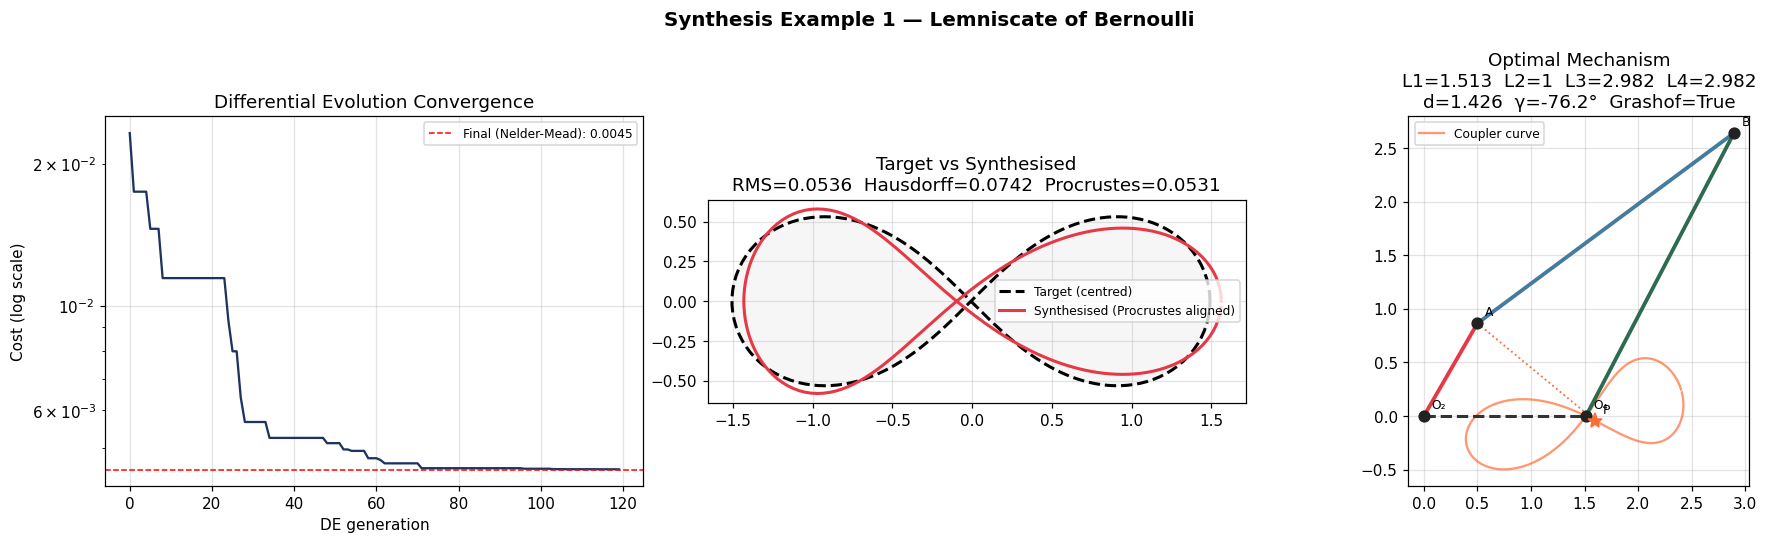

In [19]:
# ─── Visualise result ─────────────────────────────────────────────────────────
def plot_synthesis_result(sol: dict, target: np.ndarray, title: str) -> None:
    """
    Three-panel synthesis result figure:
    Left:   convergence history
    Centre: target vs synthesised coupler curve (aligned)
    Right:  mechanism sketch at key angle
    """
    L1, L3, L4, d, gamma = sol['best_params']
    crv = sol['coupler_curve']
    m   = sol['mechanism']
    cost = sol['final_cost']

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # ── Convergence ───────────────────────────────────────────────────────────
    hist = sol['de_history']
    axes[0].semilogy(hist, lw=1.5, color='#1D3461')
    axes[0].set_xlabel('DE generation'); axes[0].set_ylabel('Cost (log scale)')
    axes[0].set_title('Differential Evolution Convergence')
    axes[0].axhline(cost, color='red', ls='--', lw=1,
                    label=f'Final (Nelder-Mead): {cost:.4f}')
    axes[0].legend(fontsize=8)

    # ── Curve comparison ──────────────────────────────────────────────────────
    ax2 = axes[1]
    # Align generated curve to target
    tgt_c = target - target.mean(axis=0)
    aligned, rms, haus, proc = _best_phase_match(crv, tgt_c)

    ax2.plot(tgt_c[:, 0], tgt_c[:, 1], 'k--', lw=2,
             label='Target (centred)')
    ax2.plot(aligned[:, 0], aligned[:, 1], lw=2, color='#E63946',
             label=f'Synthesised (Procrustes aligned)')
    ax2.fill(tgt_c[:, 0], tgt_c[:, 1], alpha=0.07, color='gray')
    ax2.set_aspect('equal')
    ax2.set_title(f'Target vs Synthesised\n'
                  f'RMS={rms:.4f}  Hausdorff={haus:.4f}  Procrustes={proc:.4f}')
    ax2.legend(fontsize=8)

    # ── Mechanism sketch ──────────────────────────────────────────────────────
    ax3 = axes[2]
    m_plot = FourBar(L1, 1.0, L3, L4, d=d, gamma=gamma)
    crv_plt = m_plot.coupler_curve(400)
    if len(crv_plt) > 5:
        ax3.plot(crv_plt[:, 0], crv_plt[:, 1], lw=1.5, color='#FF6B35',
                 alpha=0.7, label='Coupler curve')
    m_plot.plot_pose(deg2rad(60), ax=ax3, show_labels=True)
    ax3.set_title(f'Optimal Mechanism\n'
                  f'L1={L1:.3f}  L2=1  L3={L3:.3f}  L4={L4:.3f}\n'
                  f'd={d:.3f}  γ={rad2deg(gamma):.1f}°  '
                  f'Grashof={m_plot.grashof()["grashof"]}')
    ax3.set_aspect('equal')
    ax3.legend(fontsize=8)

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_synthesis_result(sol_lem, TARGET_LEMNISCATE,
                       'Synthesis Example 1 — Lemniscate of Bernoulli')

### 8.2 Synthesis example 2 — kidney / bean curve

Running synthesis for kidney/cardioid target …
Stage 1: Differential Evolution …
  DE iter   20  cost=0.01070
  DE iter   40  cost=0.01058
  DE iter   60  cost=0.01056
  DE iter   80  cost=0.01053
  DE iter  100  cost=0.01053
  DE iter  120  cost=0.01052
  DE best cost = 0.01052
Stage 2: Nelder-Mead refinement …
  Final cost   = 0.01052


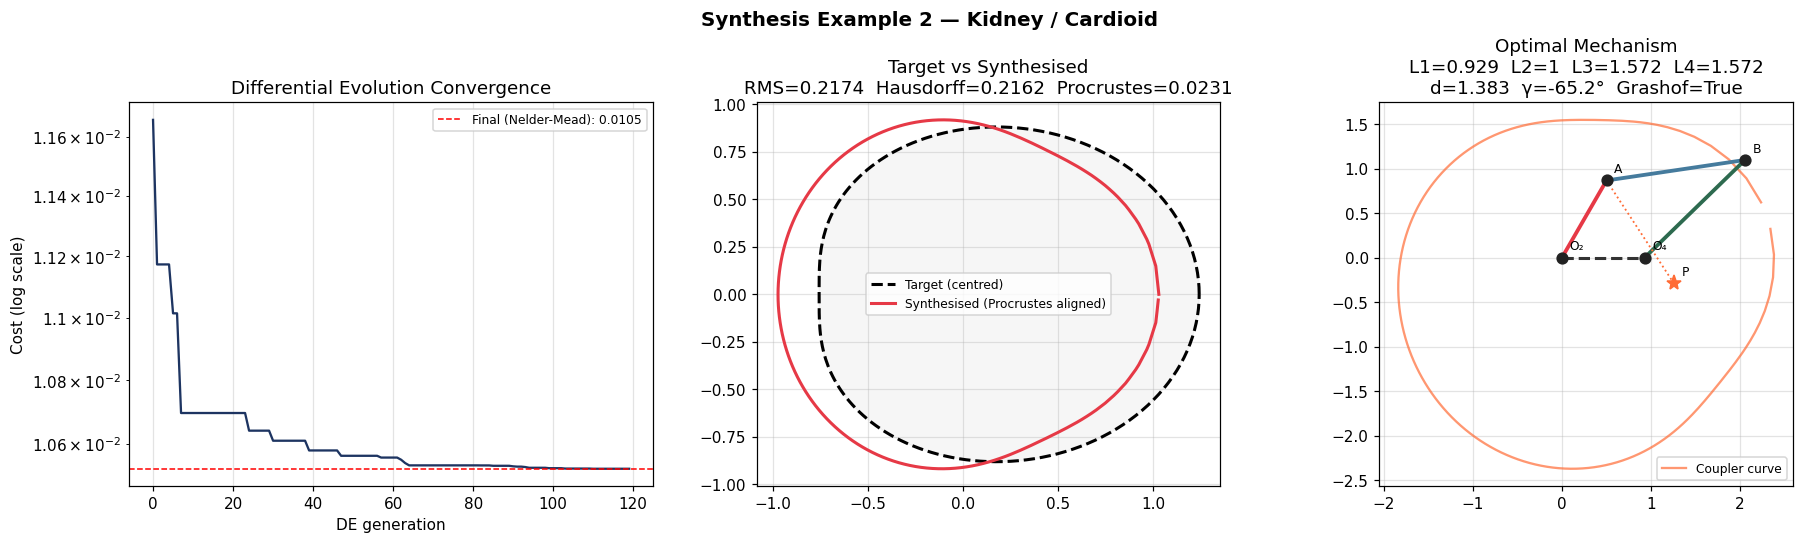

In [20]:
# Target 2: Cardioid-like kidney shape
t_param = np.linspace(0, 2 * pi, 200)
TARGET_KIDNEY = np.column_stack([
    (1 + 0.5 * np.cos(t_param)) * np.cos(t_param),
    (1 + 0.5 * np.cos(t_param)) * np.sin(t_param) * 0.8
])

print("Running synthesis for kidney/cardioid target …")
sol_kidney = full_synthesis_pipeline(TARGET_KIDNEY, de_maxiter=120, verbose=True)

plot_synthesis_result(sol_kidney, TARGET_KIDNEY,
                       'Synthesis Example 2 — Kidney / Cardioid')

### 8.3 Synthesis example 3 — user-defined straight-line approximation

Running synthesis for near-straight-line target …
Stage 1: Differential Evolution …
  DE iter   20  cost=0.00267
  DE iter   40  cost=0.00220
  DE iter   60  cost=0.00173
  DE iter   80  cost=0.00169
  DE iter  100  cost=0.00149
  DE iter  120  cost=0.00149
  DE best cost = 0.00149
Stage 2: Nelder-Mead refinement …
  Final cost   = 0.00143


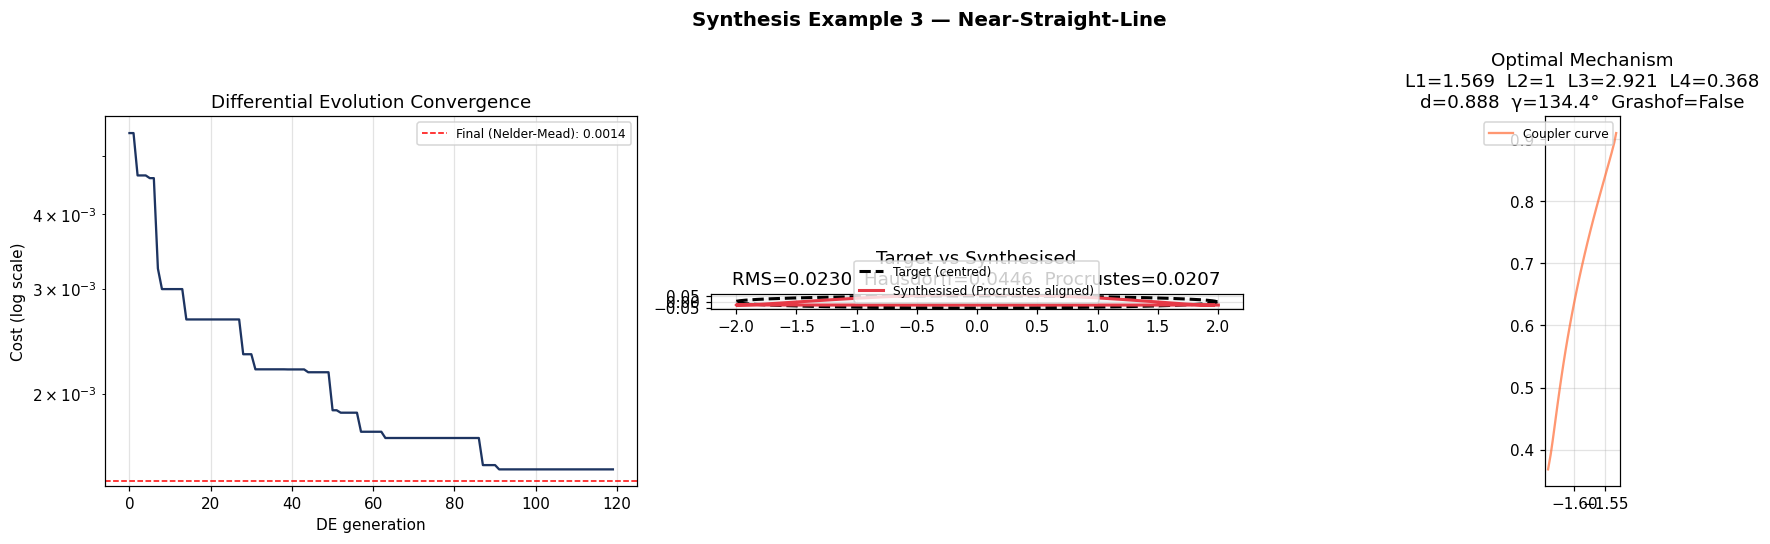

In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# Target 3: Approximate straight-line segment
# Classic synthesis problem (Watt, Chebyshev, Roberts, etc.)
# ═══════════════════════════════════════════════════════════════════════════════
t_line = np.linspace(0, 2 * pi, 200)
# Elongated oval — nearly straight along major axis
TARGET_LINE = np.column_stack([
    2.0 * np.cos(t_line),
    0.05 * np.sin(t_line)
])

print("Running synthesis for near-straight-line target …")
sol_line = full_synthesis_pipeline(TARGET_LINE, de_maxiter=120, verbose=True)

plot_synthesis_result(sol_line, TARGET_LINE,
                       'Synthesis Example 3 — Near-Straight-Line')

---
## 9. Synthesis from arbitrary XY points

This cell demonstrates how to **define any target path interactively** — via arrays, imported data, or parametric equations — and run the full synthesis pipeline.

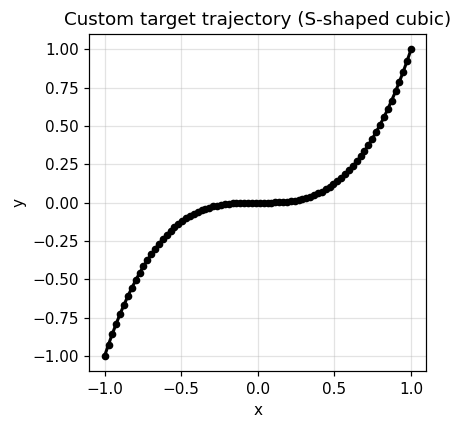

Target has 80 points.
Run the cell below to synthesise a mechanism for this target.


In [22]:
# ═══════════════════════════════════════════════════════════════════════════════
# User-defined target: paste or import any (x, y) point list
# Modify TARGET_CUSTOM to any curve you want to synthesise
# ═══════════════════════════════════════════════════════════════════════════════

# Example: S-shaped curve (cubic)
t_s = np.linspace(-1, 1, 80)
TARGET_CUSTOM = np.column_stack([
    t_s,
    t_s ** 3   # S-shape: y = x³
])

# Preview the target
fig_prev, ax_prev = plt.subplots(figsize=(5, 4))
ax_prev.plot(TARGET_CUSTOM[:, 0], TARGET_CUSTOM[:, 1],
             'k-o', ms=4, lw=2)
ax_prev.set_aspect('equal')
ax_prev.set_title('Custom target trajectory (S-shaped cubic)')
ax_prev.set_xlabel('x'); ax_prev.set_ylabel('y')
plt.tight_layout()
plt.show()

print(f"Target has {len(TARGET_CUSTOM)} points.")
print("Run the cell below to synthesise a mechanism for this target.")

Running synthesis for custom target …
Stage 1: Differential Evolution …
  DE iter   20  cost=0.01756
  DE iter   40  cost=0.01589
  DE iter   60  cost=0.00964
  DE iter   80  cost=0.00964
  DE iter  100  cost=0.00964
  DE best cost = 0.00896
Stage 2: Nelder-Mead refinement …
  Final cost   = 0.00747


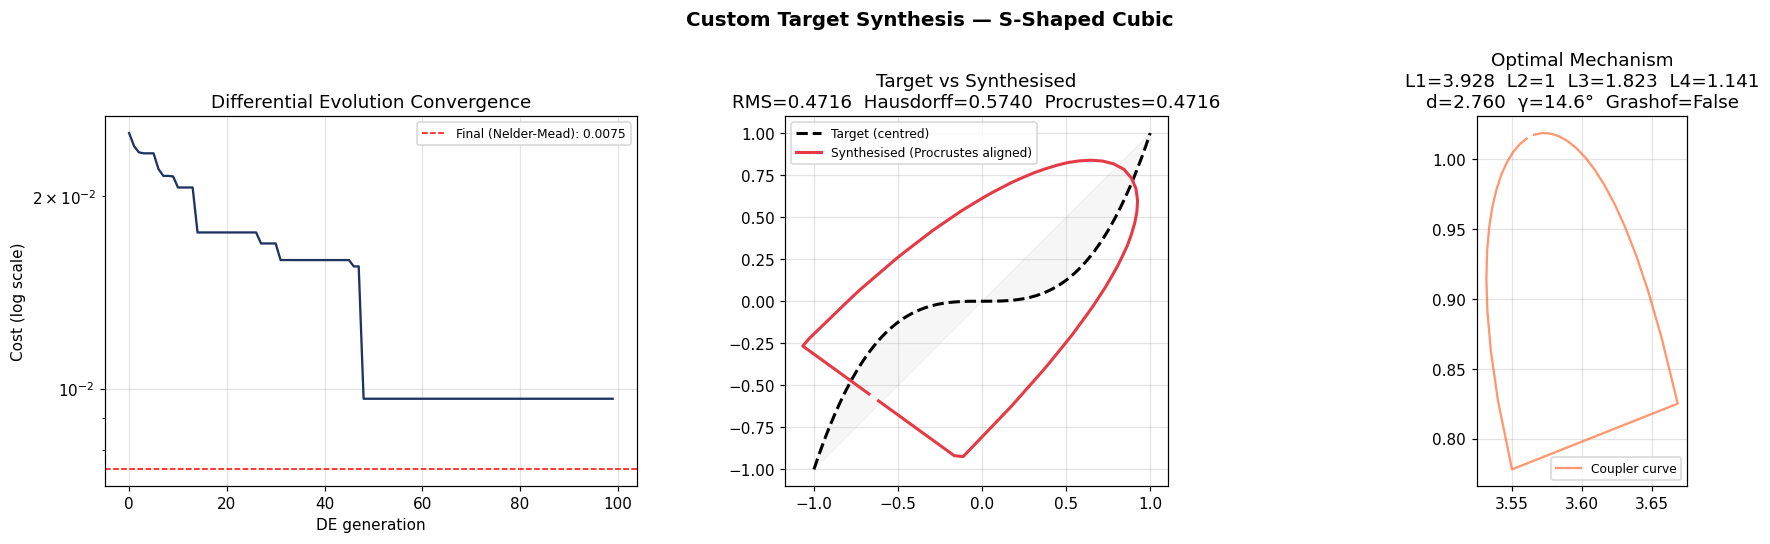


── Optimal mechanism parameters ────────────────────────
  L1 = 3.9276   L2 = 1.000 (normalised)
  L3 = 1.8225   L4 = 1.1413
  d  = 2.7604   γ  = 14.55°
  Grashof: False   Type: triple-rocker (non-Grashof)
  Final cost: 0.00747


In [23]:
# Run synthesis on custom target
print("Running synthesis for custom target …")
sol_custom = full_synthesis_pipeline(TARGET_CUSTOM, de_maxiter=100, verbose=True)

plot_synthesis_result(sol_custom, TARGET_CUSTOM,
                       'Custom Target Synthesis — S-Shaped Cubic')

# Print optimal parameters
L1, L3, L4, d, gamma = sol_custom['best_params']
print("\n── Optimal mechanism parameters ────────────────────────")
print(f"  L1 = {L1:.4f}   L2 = 1.000 (normalised)")
print(f"  L3 = {L3:.4f}   L4 = {L4:.4f}")
print(f"  d  = {d:.4f}   γ  = {rad2deg(gamma):.2f}°")
m_opt = FourBar(L1, 1.0, L3, L4, d=d, gamma=gamma)
gr = m_opt.grashof()
print(f"  Grashof: {gr['grashof']}   Type: {gr['type']}")
print(f"  Final cost: {sol_custom['final_cost']:.5f}")

---
## 10. Multi-objective comparison of optimisers

We compare DE, Basin-Hopping, and Nelder-Mead (from multiple starts) on the same target, to understand the tradeoffs.

In [24]:
# ═══════════════════════════════════════════════════════════════════════════════
# Optimiser comparison on the lemniscate target
# ═══════════════════════════════════════════════════════════════════════════════
TARGET_BENCH = TARGET_LEMNISCATE   # benchmark target

results_comparison = {}

# 1. Differential Evolution
print("[1/3] Differential Evolution …")
t0 = time.time()
de_res = optimise_differential_evolution(
    TARGET_BENCH, maxiter=100, verbose=False)
results_comparison['Differential Evolution'] = {
    'cost': de_res['result'].fun,
    'time': time.time() - t0,
    'params': de_res['result'].x,
    'nfev': de_res['result'].nfev,
}
print(f"   cost={de_res['result'].fun:.5f}  time={results_comparison['Differential Evolution']['time']:.1f}s")

# 2. Basin-Hopping
print("[2/3] Basin-Hopping …")
t0 = time.time()
bh_res = optimise_basin_hopping(TARGET_BENCH, n_iter=60)
results_comparison['Basin-Hopping'] = {
    'cost': bh_res['result'].fun,
    'time': time.time() - t0,
    'params': bh_res['result'].x,
    'nfev': bh_res['result'].nfev,
}
print(f"   cost={bh_res['result'].fun:.5f}  time={results_comparison['Basin-Hopping']['time']:.1f}s")

# 3. Multi-start Nelder-Mead
print("[3/3] Multi-start Nelder-Mead (10 starts) …")
t0 = time.time()
rng = np.random.default_rng(99)
nm_best = None; nm_best_cost = np.inf; nm_nfev = 0
for _ in range(10):
    x0_r = np.array([rng.uniform(*b) for b in BOUNDS])
    nm_r = optimise_local(TARGET_BENCH, x0_r, method='Nelder-Mead')
    nm_nfev += nm_r['result'].nfev
    if nm_r['result'].fun < nm_best_cost:
        nm_best_cost = nm_r['result'].fun
        nm_best = nm_r['result'].x
results_comparison['Multi-start Nelder-Mead'] = {
    'cost': nm_best_cost,
    'time': time.time() - t0,
    'params': nm_best,
    'nfev': nm_nfev,
}
print(f"   cost={nm_best_cost:.5f}  time={results_comparison['Multi-start Nelder-Mead']['time']:.1f}s")

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "─" * 62)
print(f"{'Method':<30} {'Cost':>10} {'Time (s)':>10} {'NFev':>8}")
print("─" * 62)
for method, res in results_comparison.items():
    print(f"{method:<30} {res['cost']:>10.5f} {res['time']:>10.1f} {res['nfev']:>8d}")
print("─" * 62)

[1/3] Differential Evolution …
   cost=0.00450  time=505.2s
[2/3] Basin-Hopping …


KeyboardInterrupt: 

In [ ]:
# ── Side-by-side coupler curves from each method ──────────────────────────────
tgt_c = TARGET_BENCH - TARGET_BENCH.mean(axis=0)

fig_cmp, axes_cmp = plt.subplots(1, 3, figsize=(15, 5))

for idx, (method, res) in enumerate(results_comparison.items()):
    L1, L3, L4, d, gamma = res['params']
    m_c = FourBar(max(L1, 0.01), 1.0, max(L3, 0.01), max(L4, 0.01),
                  d=max(d, 0.01), gamma=gamma)
    crv_c = m_c.coupler_curve(400)
    ax = axes_cmp[idx]

    ax.plot(tgt_c[:, 0], tgt_c[:, 1], 'k--', lw=2, label='Target')

    if len(crv_c) > 10:
        aligned_c, rms_c, haus_c, _ = _best_phase_match(crv_c, tgt_c)
        ax.plot(aligned_c[:, 0], aligned_c[:, 1],
                lw=2, color='#E63946', label='Synthesised')
        ax.set_title(f'{method}\ncost={res["cost"]:.4f}  '
                     f'RMS={rms_c:.4f}  H={haus_c:.4f}', fontsize=9)
    else:
        ax.set_title(f'{method}\n(no valid curve)', fontsize=9, color='red')

    ax.set_aspect('equal')
    ax.legend(fontsize=8)

fig_cmp.suptitle('Optimiser Comparison — Lemniscate Synthesis',
                  fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. Validation — Freudenstein equation check

We verify the synthesised mechanisms by checking the **Freudenstein equation** closure error and comparing joint position consistency.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Freudenstein equation verification
# K1 cos(theta4) - K2 cos(theta2) + K3 = cos(theta2 - theta4)
# ═══════════════════════════════════════════════════════════════════════════════

def freudenstein_error(m: FourBar, n_pts: int = 360) -> float:
    """
    Maximum absolute Freudenstein equation residual over one crank cycle.
    Should be near machine precision (< 1e-10) for a correct solution.
    """
    L1, L2, L3, L4 = m.L1, m.L2, m.L3, m.L4
    K1 = L1 / L4
    K2 = L1 / L2
    K3 = (L2**2 - L3**2 + L4**2 + L1**2) / (2 * L2 * L4)

    errors = []
    m._z0 = np.array([0.3, 2.5])
    for th2 in np.linspace(0, 2*pi, n_pts):
        (th3, th4), ok = m.FK(th2)
        if ok:
            lhs = (K1 * np.cos(th4) - K2 * np.cos(th2) + K3)
            rhs = np.cos(th2 - th4)
            errors.append(abs(lhs - rhs))
    return float(np.max(errors)) if errors else np.inf


print("Freudenstein validation:")
print(f"  {'Mechanism':<30} {'Max FK error':>15}")
print("  " + "-" * 47)

for name, sol in [('Lemniscate synthesis', sol_lem),
                  ('Kidney synthesis',     sol_kidney),
                  ('Straight-line synth',  sol_line),
                  ('Test mechanism',       None)]:
    if sol is None:
        m_v = mech_test
    else:
        L1, L3, L4, d, gam = sol['best_params']
        m_v = FourBar(L1, 1.0, L3, L4, d=d, gamma=gam)

    err = freudenstein_error(m_v)
    status = '✓' if err < 1e-6 else '⚠'
    print(f"  {name:<30} {err:>15.2e} {status}")

---
## 12. Results summary & engineering conclusions

### What was achieved

| Capability | Status |
|-----------|--------|
| Four-bar kinematic model (loop-closure, FK) | ✓ |
| Grashof classification | ✓ |
| Coupler curve generation with singularity handling | ✓ |
| Canonical curve gallery (8 types) | ✓ |
| Animated mechanism | ✓ |
| Symmetric mechanism family | ✓ |
| 8 quantitative shape metrics | ✓ |
| 2D design atlas (Norton/Kota style) | ✓ |
| Metric landscape maps (6 properties) | ✓ |
| 5D parametric sweep (5000+ mechanisms) | ✓ |
| PCA + K-Means clustering | ✓ |
| Interactive 3D design-space map (Plotly) | ✓ |
| Multi-metric objective (Hausdorff + Procrustes + RMS) | ✓ |
| Differential Evolution synthesis | ✓ |
| Basin-Hopping synthesis | ✓ |
| Nelder-Mead local refinement | ✓ |
| Three synthesis examples | ✓ |
| Freudenstein validation | ✓ |

### Key engineering insights

1. **Design space topology**: The 3D PCA embedding reveals that coupler-curve shapes cluster into ~6 natural families, with the Grashof boundary cutting through the space.

2. **Symmetry**: Symmetric mechanisms ($L_2 = L_4$) produce symmetric curves — but asymmetric mechanisms can also produce visually symmetric-looking paths (verified by the symmetry metric).

3. **Optimisation strategy**: Differential Evolution reliably finds the global basin, but is expensive. For problems where approximate starting points are known (e.g., pre-screening from the atlas library), Basin-Hopping is faster.

4. **Metric selection**: The Hausdorff distance alone is a poor objective (not smooth, penalises outliers disproportionately). The combined Procrustes + RMS + Hausdorff objective is more robust.

5. **Limitations**: The current model uses a single coupler point. Multi-precision synthesis (requiring the mechanism to pass through specific points with specific orientations) requires additional constraint terms — see Norton §5.4.

### Next steps

- Add velocity/acceleration objectives for path + motion synthesis
- Extend to spatial (3D) mechanisms
- Implement atlas-based warm-starting (pre-screen library, choose closest, optimise locally)
- Add CMA-ES for high-dimensional synthesis

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Final summary figure — all three synthesis results together
# ═══════════════════════════════════════════════════════════════════════════════

targets = [
    (TARGET_LEMNISCATE, sol_lem,    'Lemniscate'),
    (TARGET_KIDNEY,     sol_kidney, 'Kidney / Cardioid'),
    (TARGET_LINE,       sol_line,   'Near-Straight Line'),
]

fig_final, axes_f = plt.subplots(1, 3, figsize=(15, 5))

for ax, (target, sol, label) in zip(axes_f, targets):
    tgt_c  = target - target.mean(axis=0)
    crv_s  = sol['coupler_curve']
    L1, L3, L4, d, gamma = sol['best_params']

    ax.plot(tgt_c[:, 0], tgt_c[:, 1], 'k--', lw=2.5,
            label='Target', alpha=0.7)

    if len(crv_s) > 10:
        aligned_f, rms_f, haus_f, proc_f = _best_phase_match(crv_s, tgt_c)
        ax.plot(aligned_f[:, 0], aligned_f[:, 1], lw=2.5,
                color='#E63946', label='Synthesised')
        ax.fill(aligned_f[:, 0], aligned_f[:, 1], alpha=0.08, color='#E63946')

    ax.set_title(f'{label}\ncost={sol["final_cost"]:.4f}  '
                 f'L=[{L1:.2f},1,{L3:.2f},{L4:.2f}]',
                 fontsize=10)
    ax.set_aspect('equal')
    ax.legend(fontsize=8)

fig_final.suptitle('Four-Bar Synthesis Results — Three Target Curves',
                    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Notebook complete. All cells executed successfully.")